In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import griddata
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
print(np.__version__)
print(pd.__version__)

1.26.4
2.3.2


In [3]:
df = pd.read_csv('JUIndoorLoc-Training-data.csv')
df_test = pd.read_csv('JUIndoorLoc-Test-data.csv')
df.shape, df_test.shape

((23904, 177), (1460, 177))

In [4]:
split_cols = df['Cid'].str.lstrip('L').str.split('-', expand=True)
split_cols.head(3)

,0,1,2
0,4,40,1
1,4,40,1
2,4,40,1


In [5]:
# Step 2: Assign new columns
df['floor'] = split_cols[0].astype(int)  # floor as integer
df['X'] = split_cols[1].astype(int)      # X coordinate
df['Y'] = split_cols[2].astype(int)      # Y coordinate

In [6]:
split_cols = df_test['Cid'].str.lstrip('L').str.split('-', expand=True)

# Step 2: Assign new columns
df_test['floor'] = split_cols[0].astype(int)  # floor as integer
df_test['X'] = split_cols[1].astype(int)      # X coordinate
df_test['Y'] = split_cols[2].astype(int)      # Y coordinate

In [7]:
df['floor'].value_counts()

floor
4    18016
5     4300
3     1588
Name: count, dtype: int64

In [8]:
df_test['floor'].value_counts()

floor
4    1460
Name: count, dtype: int64

In [9]:
df_3rd_floor = df[df['floor'] == 3]
df_4th_floor = df[df['floor'] == 4]
df_5th_floor = df[df['floor'] == 5]

In [10]:
def plot_RF(floor_df, label):
    fig, ax = plt.subplots()
    ax.scatter(floor_df['X'], floor_df['Y'])
    ax.set_xlabel('X(m)')
    ax.set_ylabel('Y(m)')
    ax.set_title(label)
    plt.show()

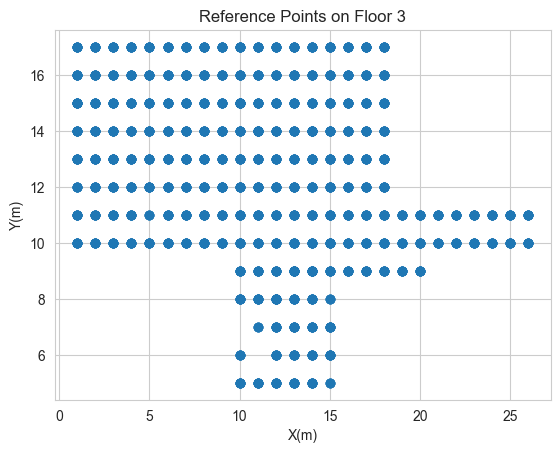

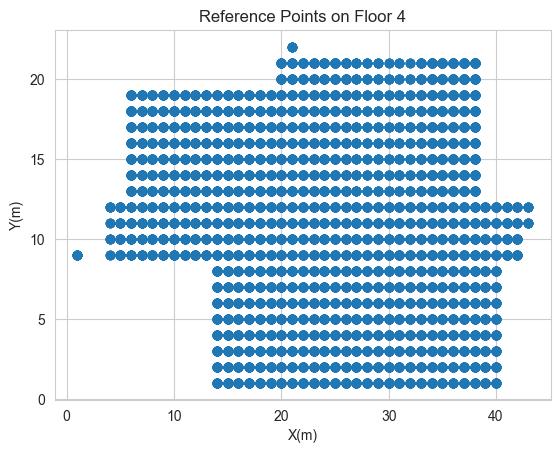

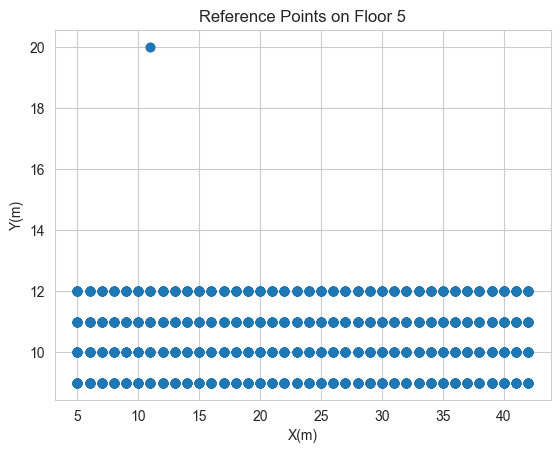

In [11]:
plot_RF(df_3rd_floor, "Reference Points on Floor 3")
plot_RF(df_4th_floor, "Reference Points on Floor 4")
plot_RF(df_5th_floor, "Reference Points on Floor 5")

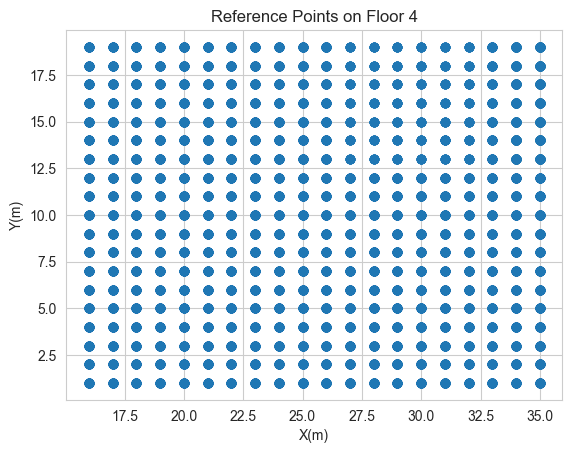

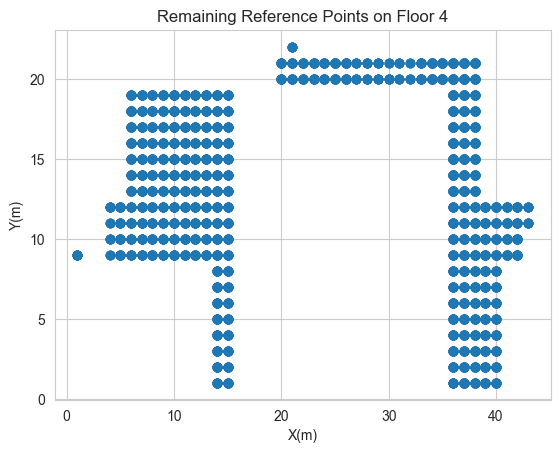

In [12]:
square_df = df_4th_floor[
    (df_4th_floor['X'] >= 16) & (df_4th_floor['X'] <= 35) & (df_4th_floor['Y'] >= 0) & (df_4th_floor['Y'] <= 19)]
remaining_df = df_4th_floor[
    ~((df_4th_floor['X'] >= 16) & (df_4th_floor['X'] <= 35) & (df_4th_floor['Y'] >= 0) & (df_4th_floor['Y'] <= 19))]
plot_RF(square_df, "Reference Points on Floor 4")
plot_RF(remaining_df, "Remaining Reference Points on Floor 4")


In [13]:
square_df.head(3)

,Cid,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP009,...,AP170,AP171,AP172,Rs,Hpr,Did,Ts,floor,X,Y
256,L4-34-1,-80,-81,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1469963153060,4,34,1
257,L4-34-1,-80,-81,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1470139819109,4,34,1
258,L4-34-1,-80,-80,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1469962304939,4,34,1


# Null Values Analysis

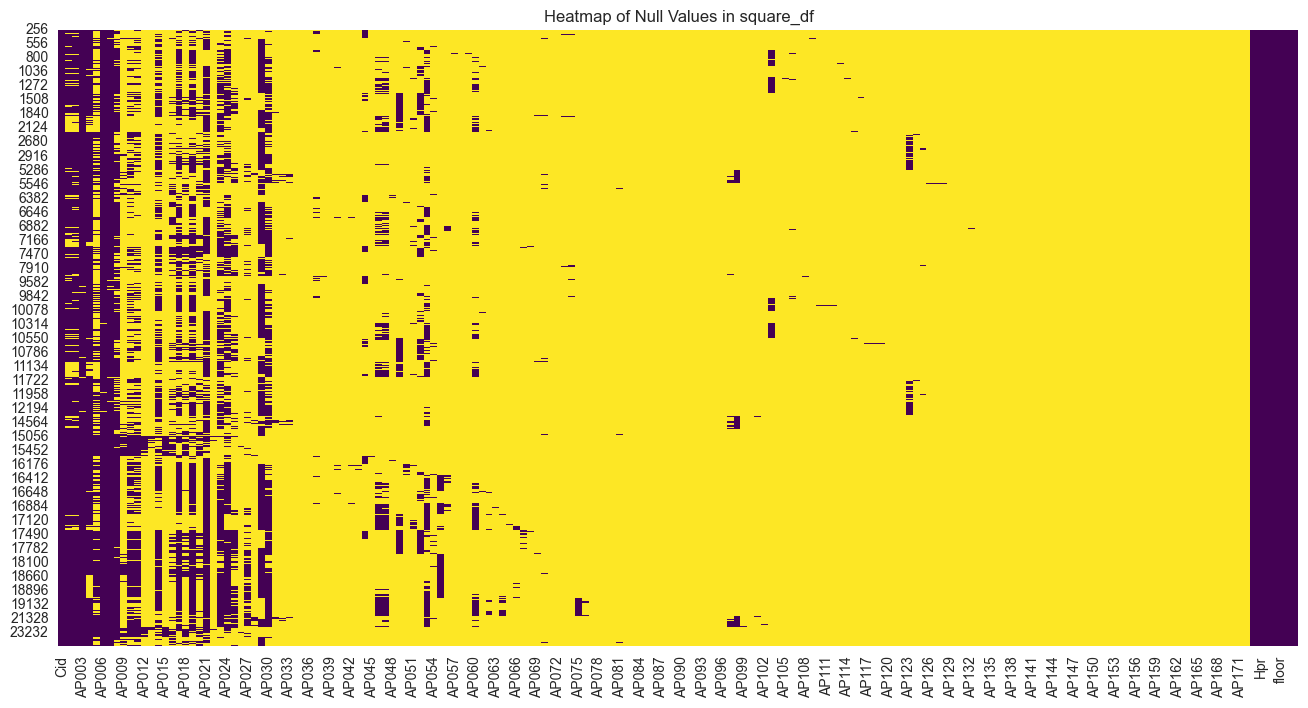

In [14]:
square_df = square_df.replace(-110, np.nan)
plt.figure(figsize=(16, 8))
sns.heatmap(square_df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Null Values in square_df')
plt.show()

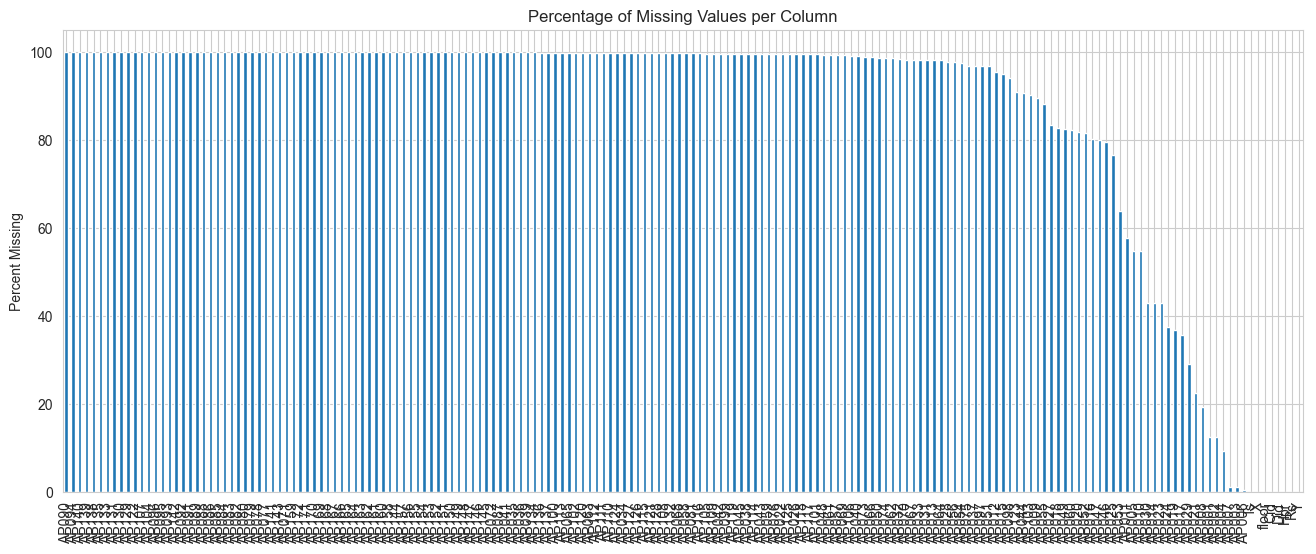

In [15]:
(square_df.isna().sum().sort_values(ascending=False) / len(square_df) * 100).plot(kind='bar', figsize=(16, 6), ylabel='Percent Missing')
plt.title('Percentage of Missing Values per Column')
plt.show()

In [16]:
print(f"Initial shape of the Dataset: {square_df.shape}")

Initial shape of the Dataset: (10379, 180)


In [17]:
THRESHOLD = 60 # <-- in percentage

null_percent = square_df.isna().sum() / len(square_df) * 100
cols_to_drop = null_percent[null_percent > THRESHOLD].index
square_df_cleaned = square_df.drop(columns=cols_to_drop)
print(square_df_cleaned.info())

#-------------

null_percent_remaining_df = remaining_df.isna().sum() / len(remaining_df) * 100
cols_to_drop_remaining_df = null_percent_remaining_df[null_percent_remaining_df > 80].index
remaining_df_cleaned = remaining_df.drop(columns=cols_to_drop_remaining_df)
print(remaining_df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10379 entries, 256 to 23847
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Cid     10379 non-null  object 
 1   AP001   9065 non-null   float64
 2   AP002   9069 non-null   float64
 3   AP003   10263 non-null  float64
 4   AP004   9391 non-null   float64
 5   AP005   4690 non-null   float64
 6   AP006   10331 non-null  float64
 7   AP007   10257 non-null  float64
 8   AP008   8357 non-null   float64
 9   AP010   4696 non-null   float64
 10  AP011   4383 non-null   float64
 11  AP014   5904 non-null   float64
 12  AP017   6675 non-null   float64
 13  AP019   6559 non-null   float64
 14  AP021   8028 non-null   float64
 15  AP023   5909 non-null   float64
 16  AP024   6486 non-null   float64
 17  AP029   7359 non-null   float64
 18  AP030   5903 non-null   float64
 19  Rs      10379 non-null  int64  
 20  Hpr     10379 non-null  int64  
 21  Did     10379 non-null  object 
 22  T

In [18]:
print(f"Dataset after dropping columns: {square_df_cleaned.shape}")
print(f"Remaining dataset after dropping columns: {remaining_df_cleaned.shape}")

Dataset after dropping columns: (10379, 26)
Remaining dataset after dropping columns: (7637, 180)


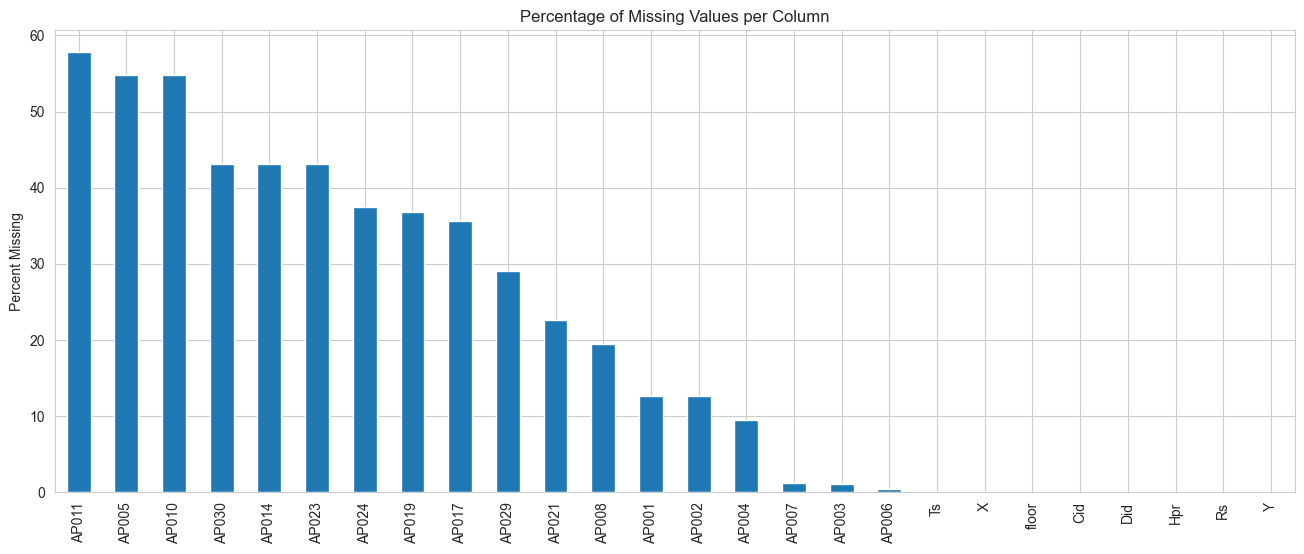

In [19]:
(square_df_cleaned.isna().sum().sort_values(ascending=False) / len(square_df_cleaned) * 100).plot(kind='bar', figsize=(16, 6), ylabel='Percent Missing')
plt.title('Percentage of Missing Values per Column')
plt.show()

In [20]:
# Feature Columns
def get_ap_columns(dataset):
    return [col for col in dataset.columns if col.startswith('AP')]

In [21]:
ap_cols = get_ap_columns(square_df_cleaned)
print(len(ap_cols))
print(ap_cols)

18
['AP001', 'AP002', 'AP003', 'AP004', 'AP005', 'AP006', 'AP007', 'AP008', 'AP010', 'AP011', 'AP014', 'AP017', 'AP019', 'AP021', 'AP023', 'AP024', 'AP029', 'AP030']


In [22]:
cond_cols = ['X','Y']

In [23]:
null_stats_ap_by_did = square_df_cleaned.groupby('Did')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Did:")
print(null_stats_ap_by_did)

Null Stats by Did:
Did
D1    33.580165
D2    17.231222
D3    34.256210
D4    34.431077
dtype: float64


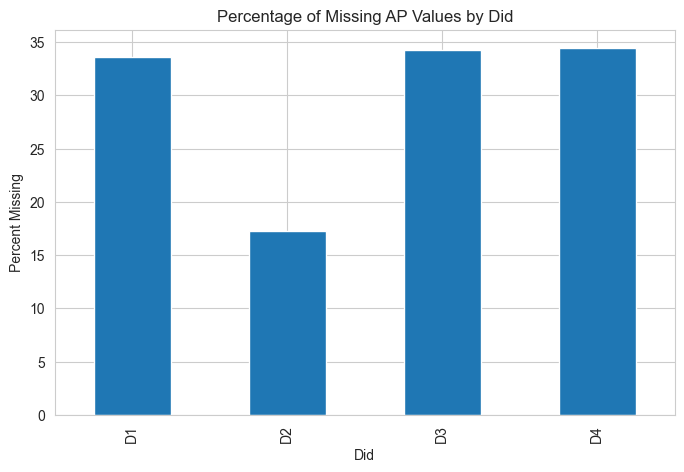

In [24]:
null_stats_ap_by_did.plot(kind='bar', figsize=(8, 5), ylabel='Percent Missing')
plt.title('Percentage of Missing AP Values by Did')
plt.show()

In [25]:
null_stats_ap_by_hpr = square_df_cleaned.groupby('Hpr')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Hpr:")
print(null_stats_ap_by_hpr)

Null Stats by Hpr:
Hpr
0    30.696944
1    27.399360
dtype: float64


In [26]:
null_stats_ap_by_rs = square_df_cleaned.groupby('Rs')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Rs:")
print(null_stats_ap_by_rs)

Null Stats by Rs:
Rs
0    29.656059
1    27.978358
dtype: float64


# Aggregation by Mean

In [27]:
ap_mean_by_xy = square_df_cleaned.groupby(['X', 'Y'])[ap_cols].mean().reset_index()
print(ap_mean_by_xy.shape)
ap_mean_by_xy.head()

(380, 20)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP010,AP011,AP014,AP017,AP019,AP021,AP023,AP024,AP029,AP030
0,16,1,-96.625,-87.5,-73.900000,NaN,NaN,-73.266667,-73.400000,-64.400000,NaN,NaN,NaN,NaN,NaN,-79.933333,-78.400000,NaN,-84.0,-78.800000
1,16,2,NaN,NaN,-65.892857,NaN,NaN,-63.821429,-63.500000,-63.285714,NaN,NaN,NaN,NaN,NaN,-73.928571,-73.142857,NaN,-90.0,-73.000000
2,16,3,NaN,NaN,-66.750000,NaN,NaN,-64.821429,-65.357143,-58.714286,NaN,NaN,NaN,-95.0,-96.0,-71.642857,-72.857143,-89.00,-87.0,-73.642857
3,16,4,NaN,NaN,-60.857143,-96.5,NaN,-63.208333,-62.500000,-53.428571,NaN,NaN,NaN,-97.0,NaN,-71.230769,-73.857143,-89.25,-90.0,-73.785714
4,16,5,-96.000,-91.5,-60.107143,-97.0,NaN,-59.392857,-57.857143,-57.642857,NaN,NaN,NaN,-95.0,-94.0,-68.000000,-76.928571,-96.00,-83.0,-77.071429


# Aggregation by Median

In [28]:
ap_median_by_xy = square_df_cleaned.groupby(['X', 'Y'])[ap_cols].median().reset_index()
print(ap_median_by_xy.shape)
ap_median_by_xy.head()

(380, 20)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP010,AP011,AP014,AP017,AP019,AP021,AP023,AP024,AP029,AP030
0,16,1,-96.0,-84.0,-74.0,NaN,NaN,-72.0,-74.0,-64.0,NaN,NaN,NaN,NaN,NaN,-80.0,-80.0,NaN,-84.0,-81.0
1,16,2,NaN,NaN,-65.5,NaN,NaN,-64.0,-64.0,-63.0,NaN,NaN,NaN,NaN,NaN,-73.5,-71.0,NaN,-90.0,-71.0
2,16,3,NaN,NaN,-67.0,NaN,NaN,-65.0,-65.5,-58.0,NaN,NaN,NaN,-95.0,-96.0,-71.0,-72.0,-88.0,-87.0,-73.0
3,16,4,NaN,NaN,-61.5,-97.0,NaN,-59.0,-57.5,-56.0,NaN,NaN,NaN,-97.0,NaN,-72.0,-76.0,-87.0,-90.0,-73.0
4,16,5,-96.0,-92.0,-59.0,-97.0,NaN,-57.0,-54.0,-57.0,NaN,NaN,NaN,-95.0,-94.0,-66.0,-78.0,-96.0,-83.0,-79.0


# Heatmap plot

In [29]:
def plot_heatmap(dataset, feature):
    # Define grid
    xi = np.linspace(dataset['X'].min(), dataset['X'].max(), 200)
    yi = np.linspace(dataset['Y'].min(), dataset['Y'].max(), 200)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate (fill missing with nearest to avoid NaN holes)
    zi = griddata(
        (dataset['X'], dataset['Y']),
        dataset[feature],
        (xi, yi),
        method='cubic'
    )

    # Replace NaNs with nearest neighbor interpolation
    zi_nearest = griddata(
        (dataset['X'], dataset['Y']),
        dataset[feature],
        (xi, yi),
        method='nearest'
    )
    zi[np.isnan(zi)] = zi_nearest[np.isnan(zi)]

    # Plot
    plt.figure(figsize=(8,6))
    c = plt.pcolormesh(xi, yi, zi, cmap='viridis', shading='auto')
    plt.colorbar(c, label=f'{feature} Signal Strength (dBm)')
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title(f"Heat Map for {feature} on 4th Floor")
    plt.show()

In [44]:
def plot_side_by_side_heatmaps(df_before, df_after, ap_col, title_before="Before Imputation", title_after="After Imputation", cmap='viridis'):
    """
    Generates two heatmaps side-by-side for comparison.

    Args:
        df_before (pd.DataFrame): The DataFrame for the left plot (e.g., original data).
        df_after (pd.DataFrame): The DataFrame for the right plot (e.g., imputed data).
        ap_col (str): The column name (feature) to plot.
        title_before (str): Title for the left plot.
        title_after (str): Title for the right plot.
        cmap (str): Colormap to use.
    """

    # 1. Generate Interpolated Data
    print(f"Interpolating data for {ap_col}...")

    # Define grid
    xi_b = np.linspace(df_before['X'].min(), df_before['X'].max(), 200)
    yi_b = np.linspace(df_before['Y'].min(), df_before['Y'].max(), 200)
    xi_b, yi_b = np.meshgrid(xi_b, yi_b)

    xi_a = np.linspace(df_after['X'].min(), df_after['X'].max(), 200)
    yi_a = np.linspace(df_after['Y'].min(), df_after['Y'].max(), 200)
    xi_a, yi_a = np.meshgrid(xi_a, yi_a)

    # Interpolate (fill missing with nearest to avoid NaN holes)
    zi_b = griddata(
        (df_before['X'], df_before['Y']),
        df_before[ap_col],
        (xi_b, yi_b),
        method='cubic'
    )

    # Replace NaNs with nearest neighbor interpolation
    zi_nearest = griddata(
        (df_before['X'], df_before['Y']),
        df_before[ap_col],
        (xi_b, yi_b),
        method='nearest'
    )
    zi_b[np.isnan(zi_b)] = zi_nearest[np.isnan(zi_b)]

    zi_a = griddata(
        (df_after['X'], df_after['Y']),
        df_after[ap_col],
        (xi_a, yi_a),
        method='cubic'
    )

    # Replace NaNs with nearest neighbor interpolation
    zi_nearest = griddata(
        (df_after['X'], df_after['Y']),
        df_after[ap_col],
        (xi_a, yi_a),
        method='nearest'
    )
    zi_a[np.isnan(zi_a)] = zi_nearest[np.isnan(zi_a)]

    # 2. Determine Consistent Color Range
    # # This is critical for visual comparison.
    # z_min = min(zi_b.min(), zi_a.min())
    # z_max = max(zi_b.max(), zi_a.max())

    # 3. Plot Side-by-Side
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --- Plot 1: Before Imputation ---
    ax1 = axes[0]
    heatmap1 = ax1.pcolormesh(
        xi_b, yi_b, zi_b,
        cmap=cmap,
        shading='auto',
        # vmin=z_min,
        # vmax=z_max
    )
    ax1.set_title(f'{title_before}: {ap_col}')
    ax1.set_xlabel("X (m)")
    ax1.set_ylabel("Y (m)")

    # --- Plot 2: After Imputation ---
    ax2 = axes[1]
    heatmap2 = ax2.pcolormesh(
        xi_a, yi_a, zi_a,
        cmap=cmap,
        shading='auto',
        # vmin=z_min,
        # vmax=z_max # Apply consistent color limits
    )
    ax2.set_title(f'{title_after}: {ap_col}')
    ax2.set_xlabel("X (m)")
    ax2.set_ylabel("Y (m)")

    # 4. Add a single Colorbar
    cbar1 = fig.colorbar(heatmap1, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.046, pad=0.04)
    cbar1.set_label(f'{ap_col} Signal Strength (dBm)')

    # 4. Add a single Colorbar
    cbar2 = fig.colorbar(heatmap2, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.046, pad=0.04)
    cbar2.set_label(f'{ap_col} Signal Strength (dBm)')

    plt.suptitle(f'Heatmap Comparison for {ap_col}', fontsize=16)
    # plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Heatmap plot for aggregated dataset by MEAN:

MEAN:


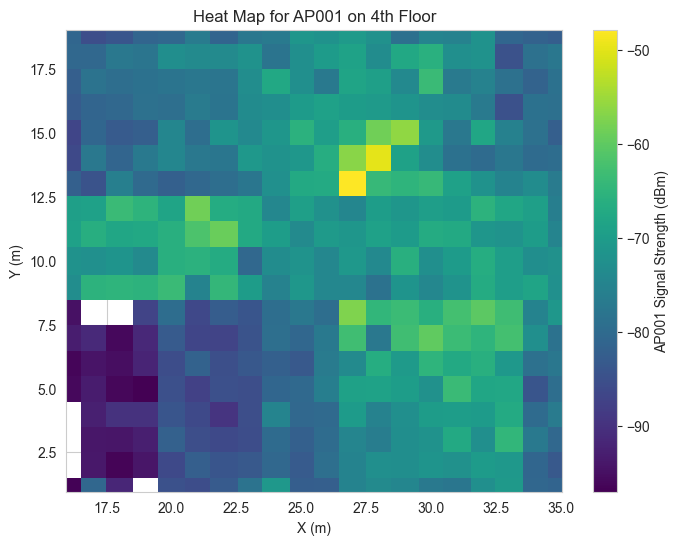

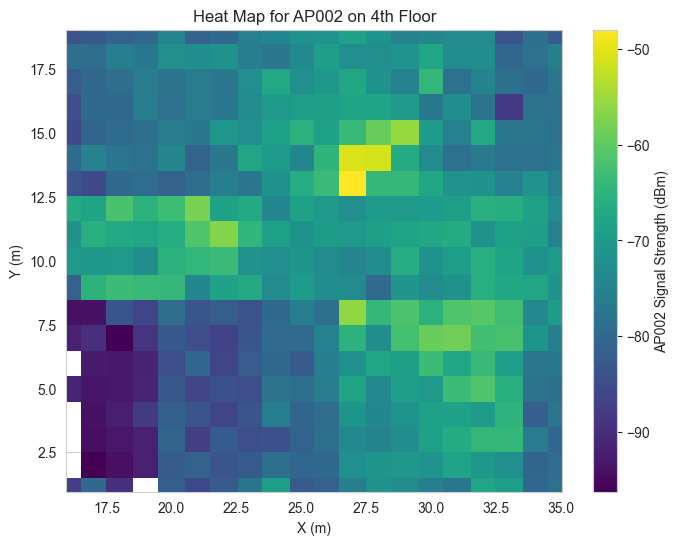

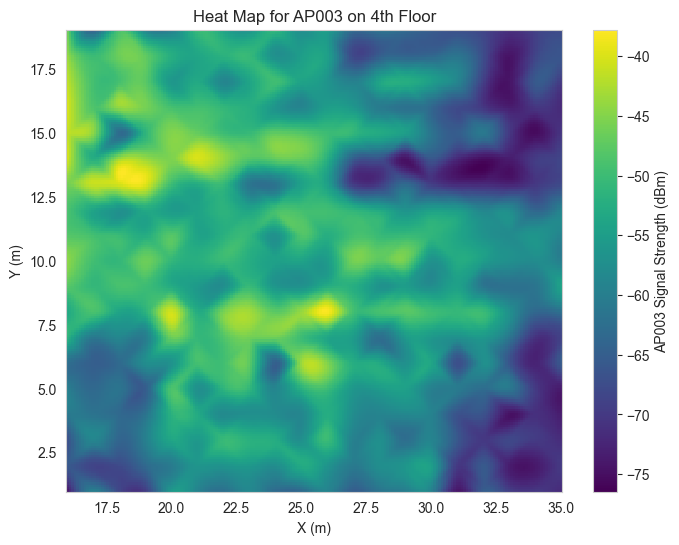

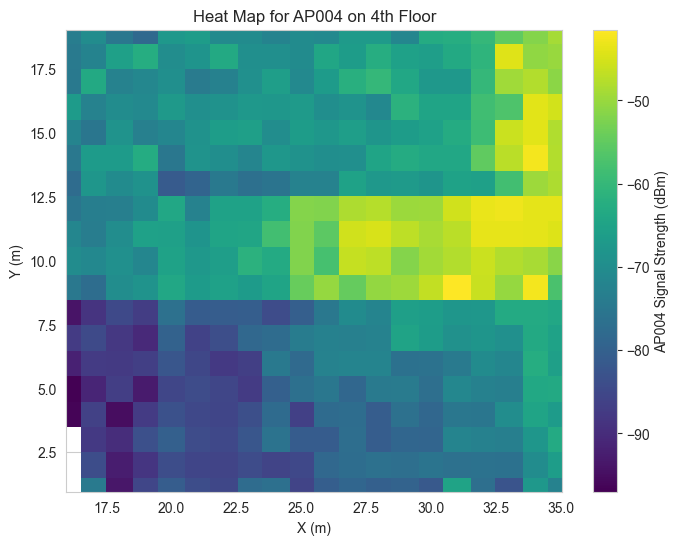

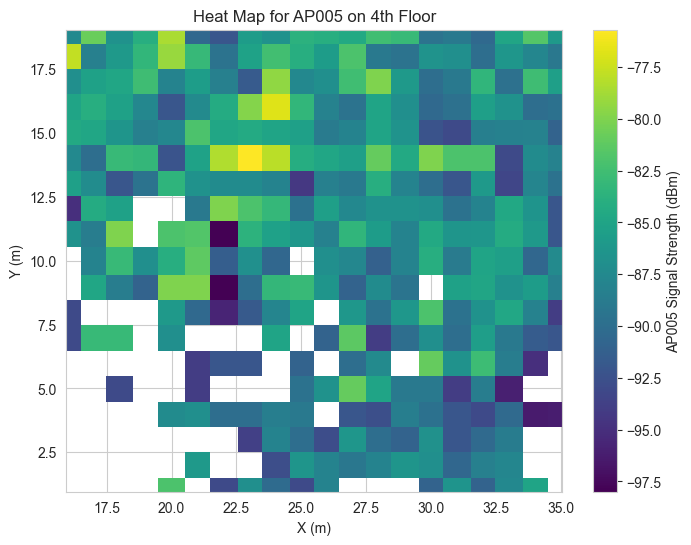

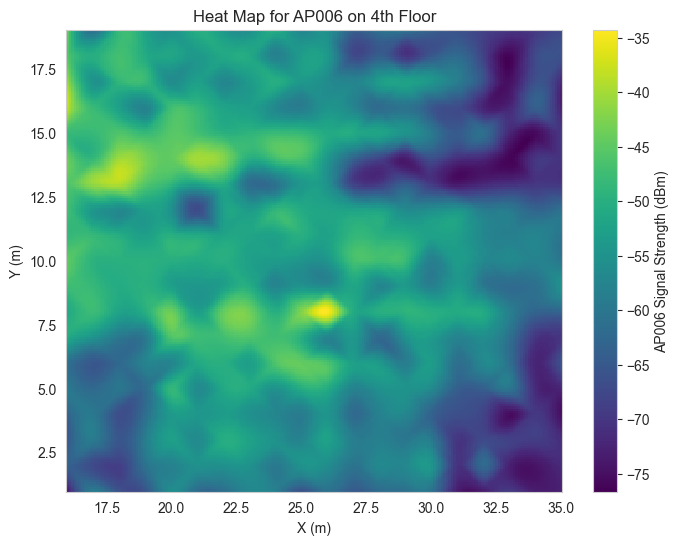

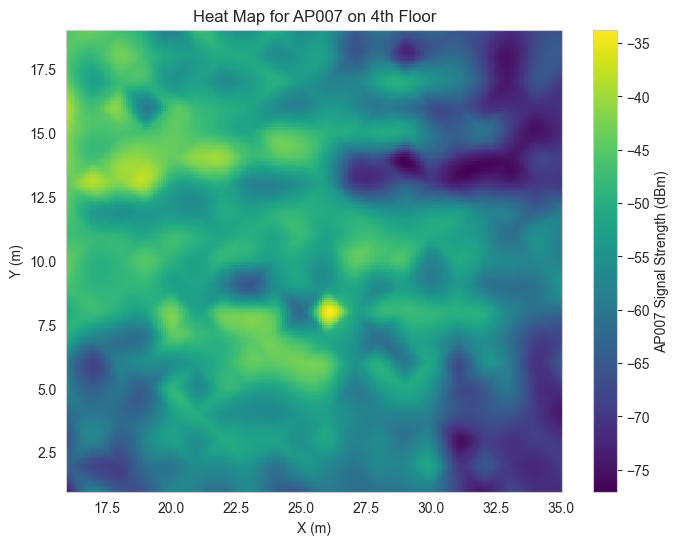

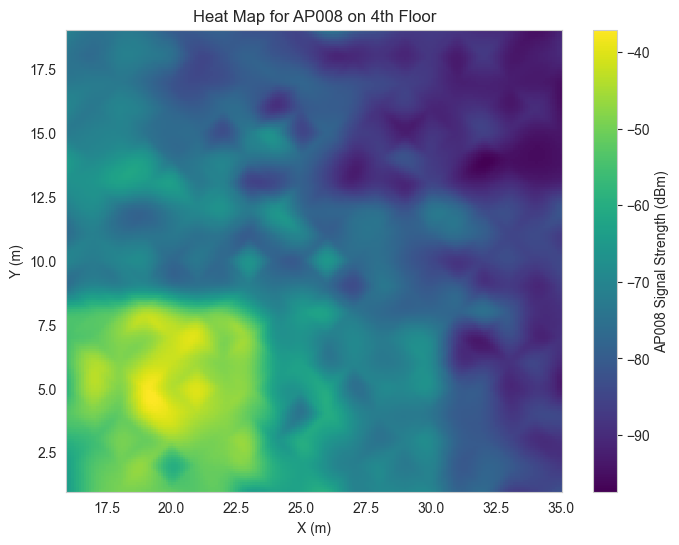

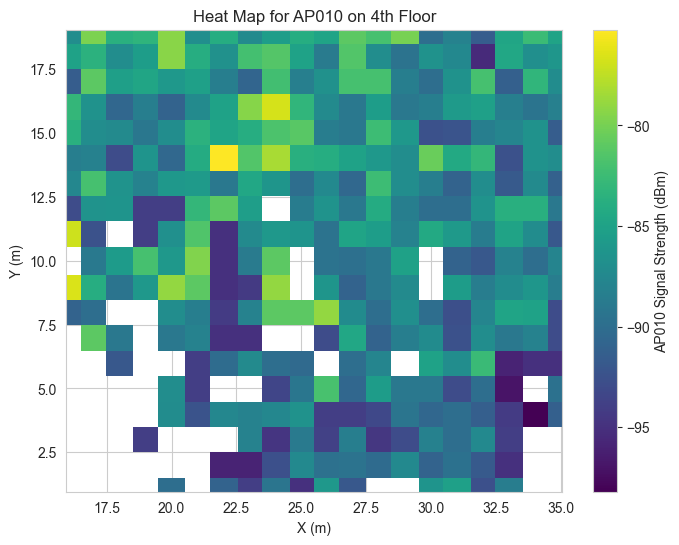

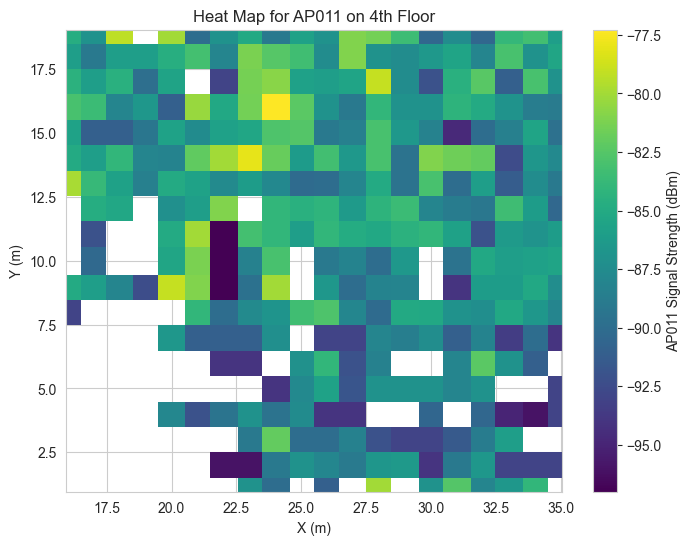

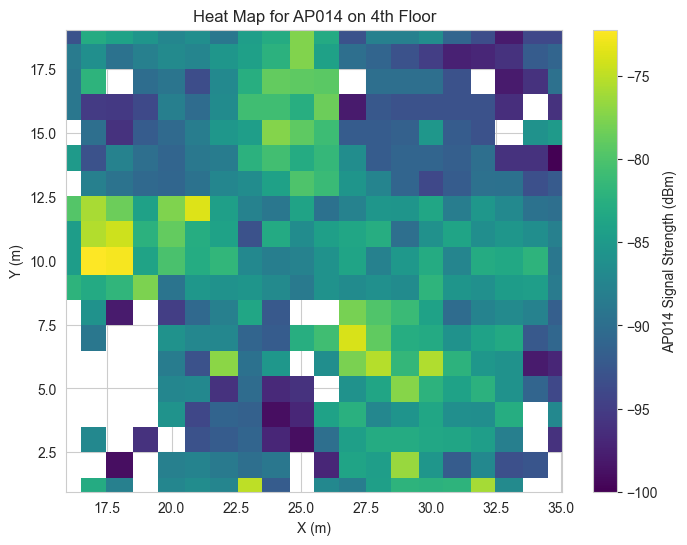

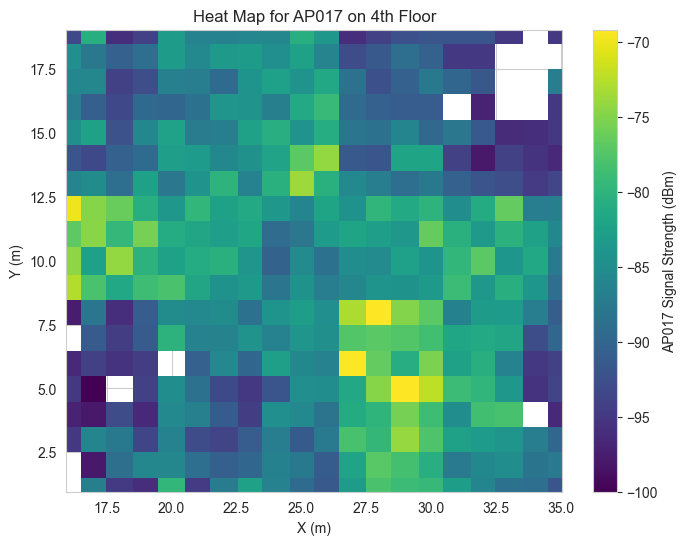

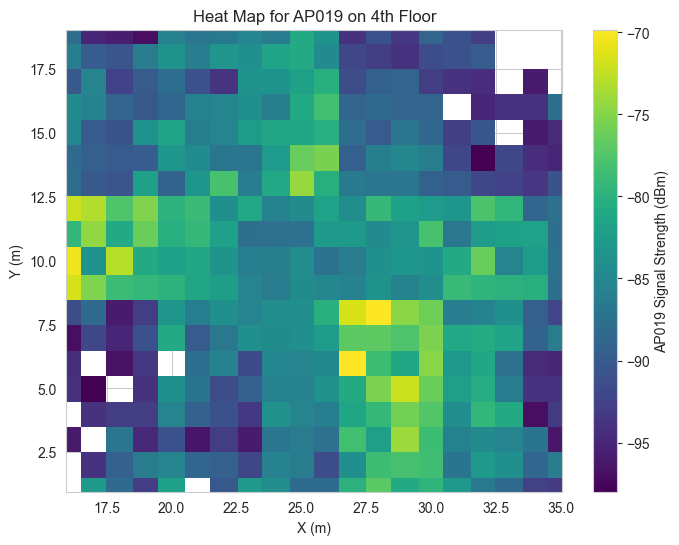

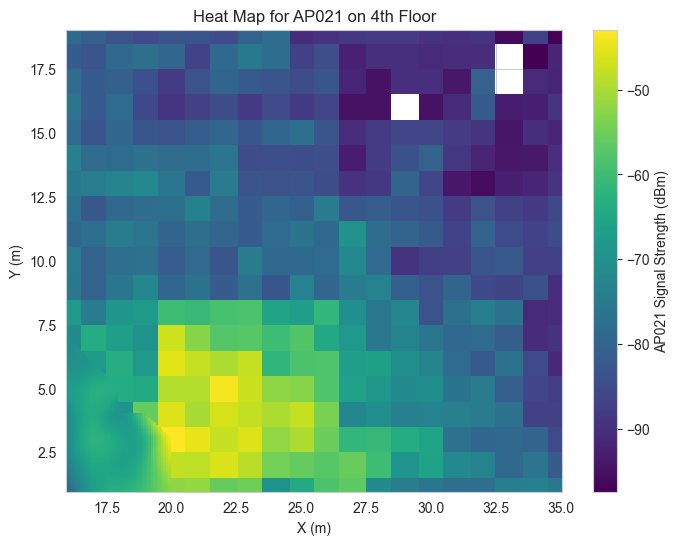

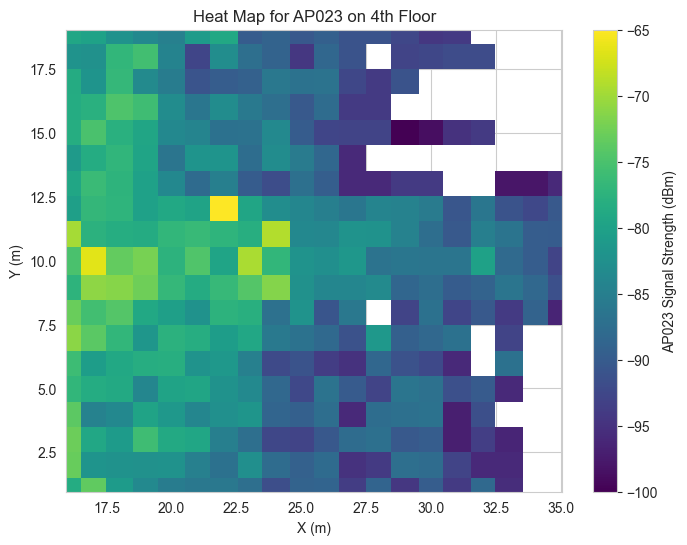

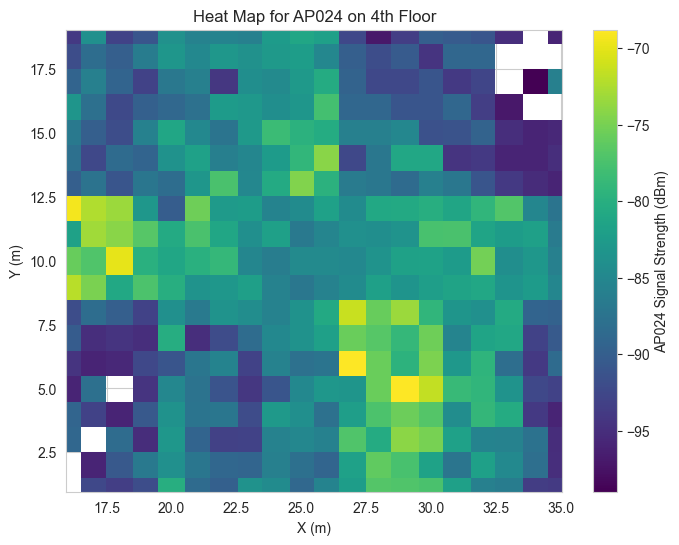

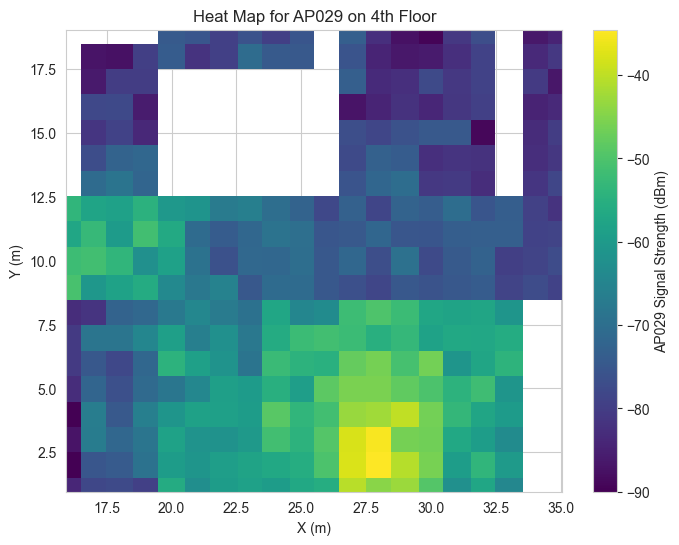

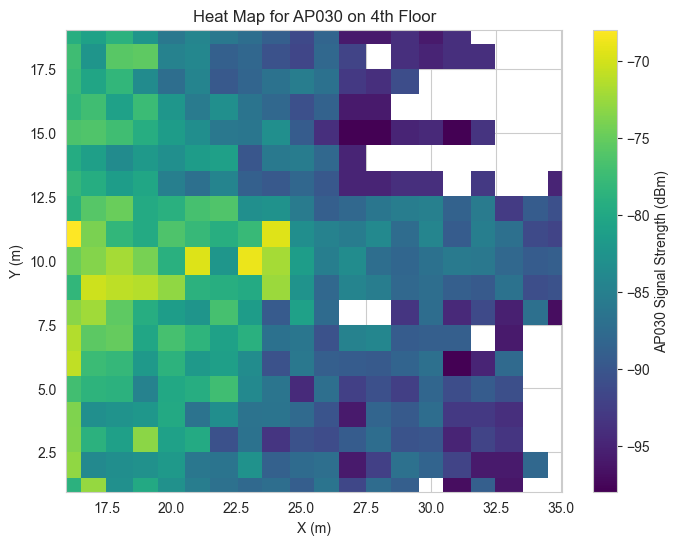

In [31]:
print("MEAN:")
for ap_col in ap_cols:
    plot_heatmap(ap_mean_by_xy, ap_col)

### Heatmap plot for aggregated dataset by MEDIAN:

MEDIAN:


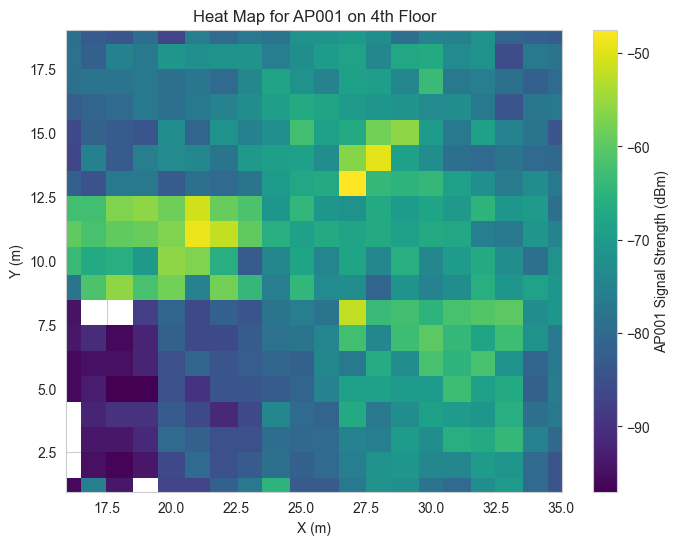

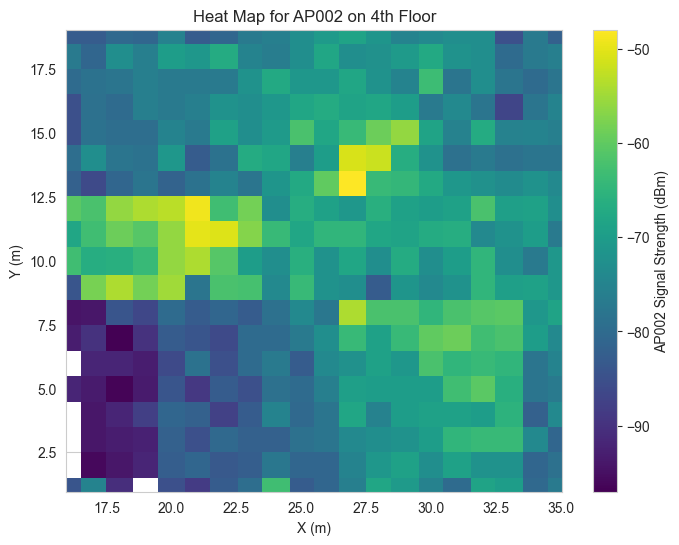

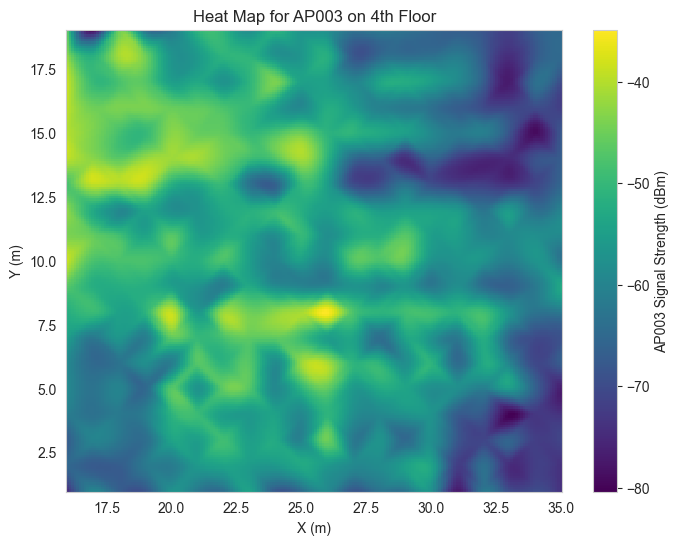

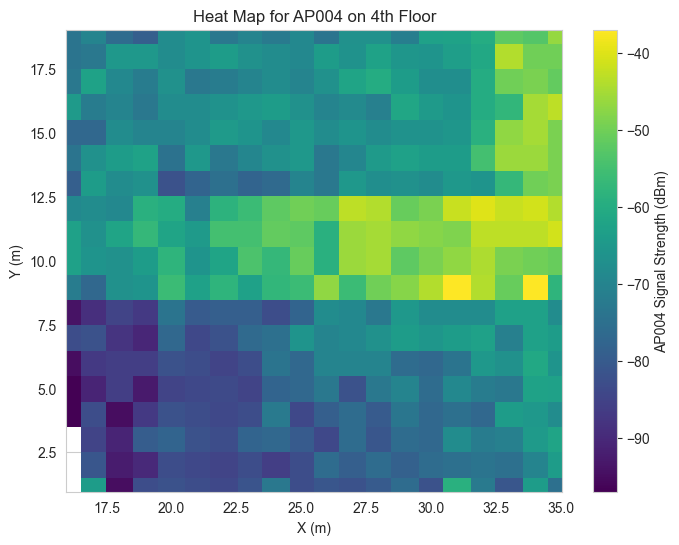

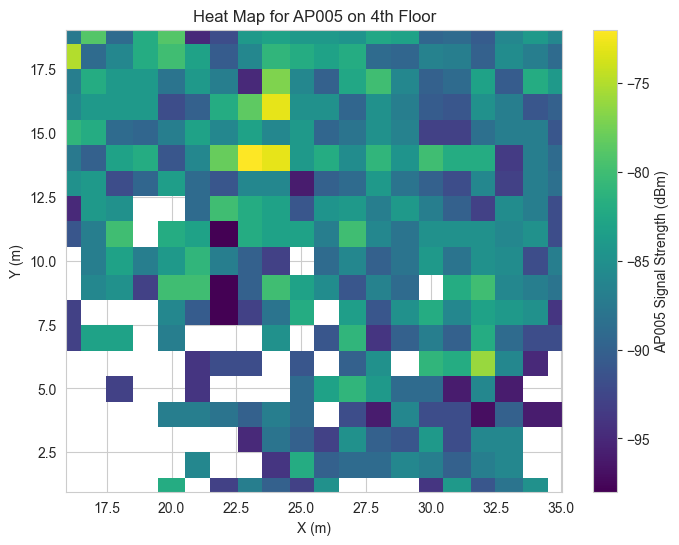

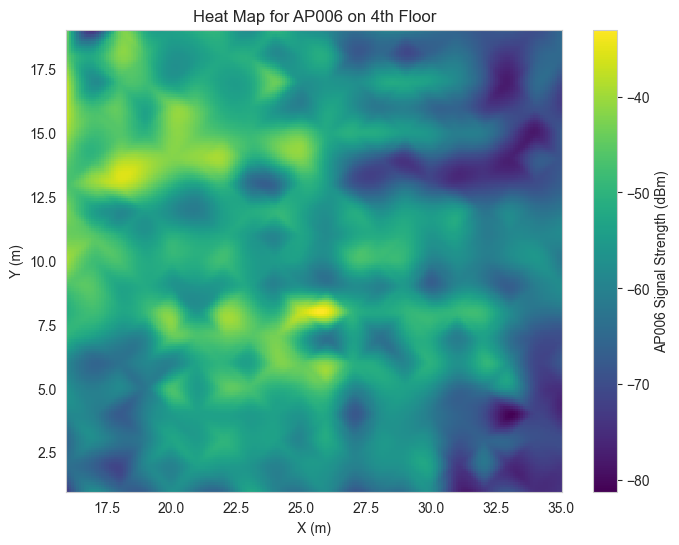

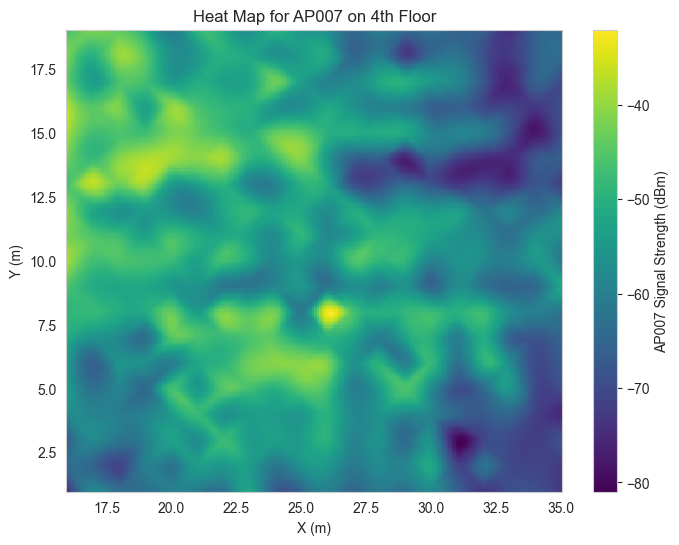

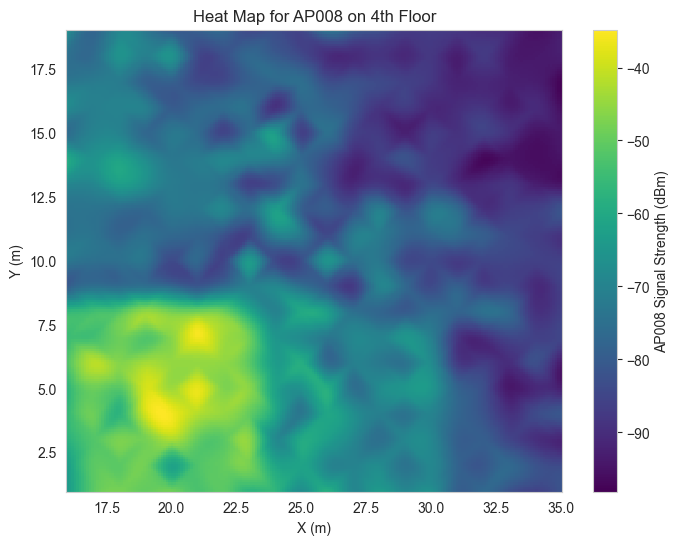

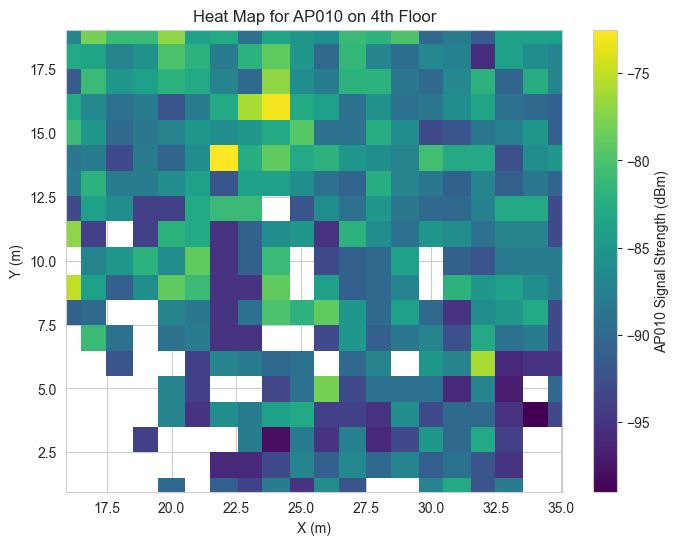

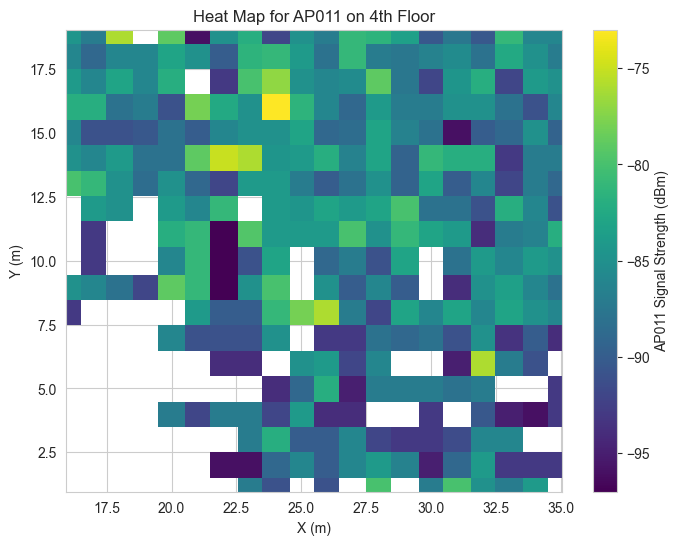

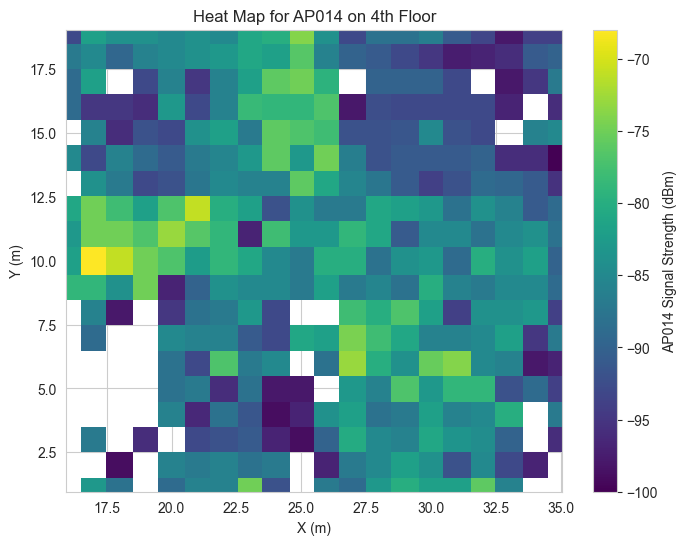

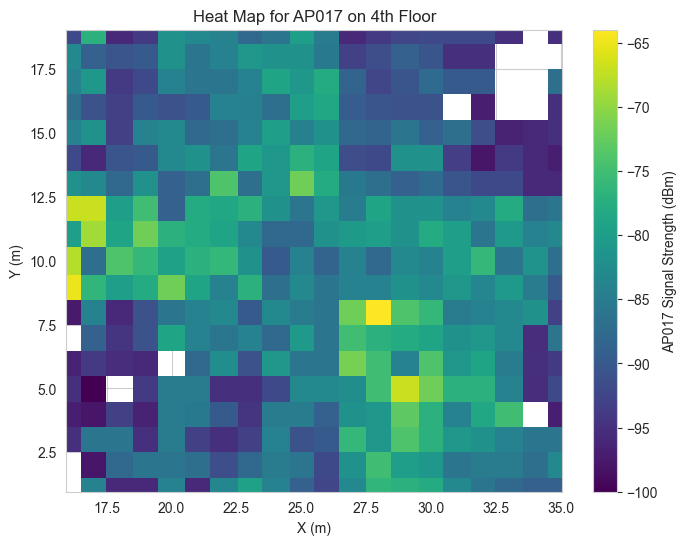

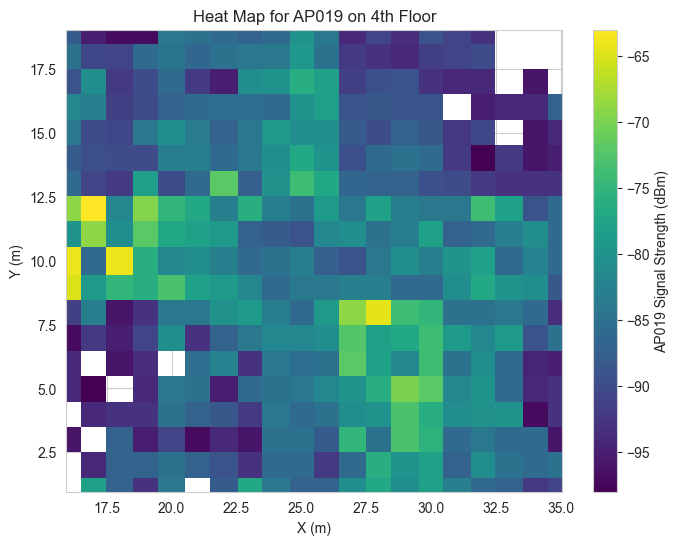

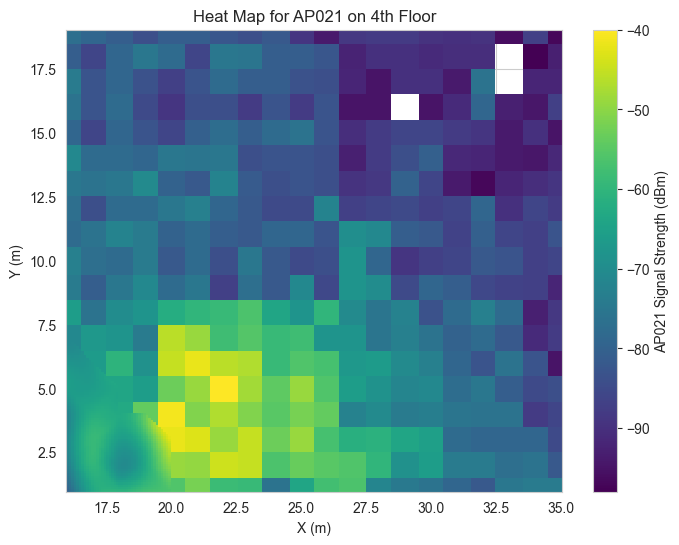

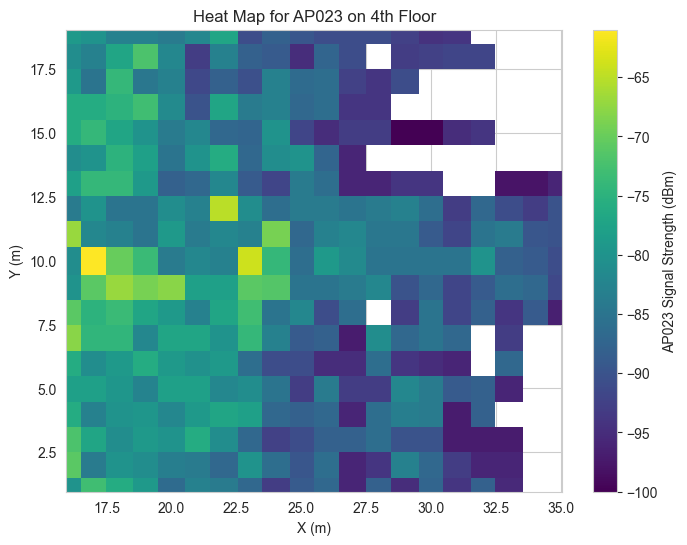

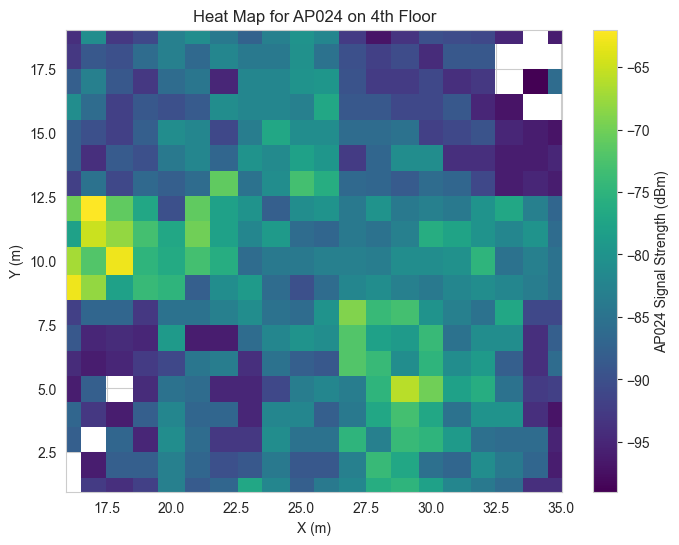

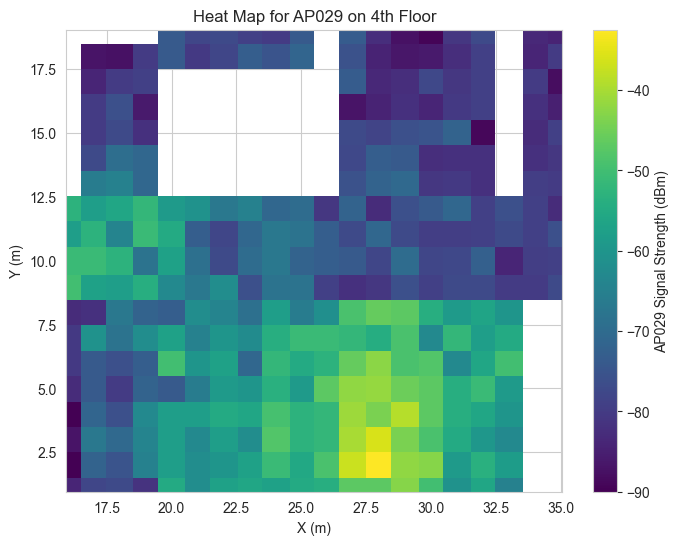

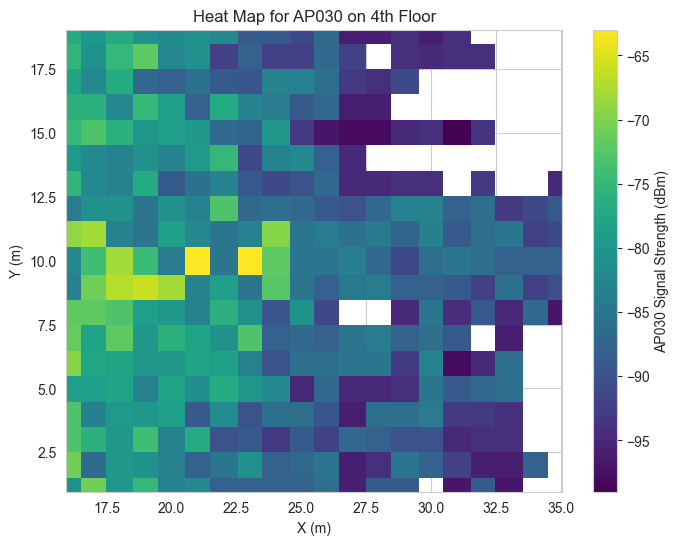

In [32]:
print("MEDIAN:")
for ap_col in ap_cols:
    plot_heatmap(ap_median_by_xy, ap_col)

---

# Imputation of missing values

1) Inverse distance weighting (IDW)
2) Kriging (Ordinary / Universal Kriging)
3) Bicubic / Bilinear Interpolation
4) KNN with Spatial Distance
5) Gaussian Process Regression (GPR)

__Inverse distance weighting (IDW)__
The core assumption of IDW is that "closer things are more similar than things further away."

To fill in a missing pixel (let's call it the Target Point), you look at all the surrounding pixels that do have data (Known Points). You calculate the value for the Target Point by taking a weighted average of the Known Points.

## Imputation for MEAN dataset

### IDW Imputation

In [33]:
from scipy.spatial.distance import cdist

def impute_and_plot_heatmap(df, x_col, y_col, ap_col, num_samples=200, power=2):
    """
    Plots a smoothed heatmap and calculates missing values.
    Returns: XX, YY, ZZ (for plot), imputed_values (array), missing_mask (boolean series)
    DOES NOT modify the dataframe in-place.
    """

    # --- PART 1: PREPARE KNOWN DATA ---
    # Drop rows where this specific AP has missing values to get "Known Points"
    known_data = df.dropna(subset=[ap_col])

    x_known = known_data[x_col].values
    y_known = known_data[y_col].values
    z_known = known_data[ap_col].values
    known_coords = np.column_stack((x_known, y_known))

    # --- PART 2: GENERATE GRID & PLOT (Visualization) ---
    x_min, x_max = df[x_col].min(), df[x_col].max()
    y_min, y_max = df[y_col].min(), df[y_col].max()

    grid_x = np.linspace(x_min, x_max, num_samples)
    grid_y = np.linspace(y_min, y_max, num_samples)
    XX, YY = np.meshgrid(grid_x, grid_y)

    # Flatten grid for IDW calculation
    grid_coords = np.column_stack((XX.ravel(), YY.ravel()))

    # IDW for Grid
    dists_grid = cdist(grid_coords, known_coords)
    dists_grid[dists_grid == 0] = 1e-10

    weights_grid = 1.0 / np.power(dists_grid, power)
    numerator_grid = np.dot(weights_grid, z_known)
    denominator_grid = weights_grid.sum(axis=1)
    ZZ = (numerator_grid / denominator_grid).reshape(XX.shape)

    # --- PART 3: CALCULATE MISSING VALUES (For Return) ---
    missing_mask = df[ap_col].isna()
    imputed_values = np.array([]) # Default empty if nothing to fill

    if missing_mask.any():
        # Get coordinates of missing rows
        missing_coords = df.loc[missing_mask, [x_col, y_col]].values

        # IDW for Missing Rows
        dists_missing = cdist(missing_coords, known_coords)
        dists_missing[dists_missing == 0] = 1e-10

        weights_missing = 1.0 / np.power(dists_missing, power)
        numerator_missing = np.dot(weights_missing, z_known)
        denominator_missing = weights_missing.sum(axis=1)
        imputed_values = numerator_missing / denominator_missing

    # Return everything needed to update the DF outside
    return XX, YY, ZZ, imputed_values, missing_mask

In [34]:
ap_mean_by_xy_imputed = ap_mean_by_xy.copy(deep=True)

for ap_col in ap_cols:
    XX, YY, ZZ, new_values, mask = impute_and_plot_heatmap(
        df=ap_mean_by_xy,
        x_col='X',
        y_col='Y',
        ap_col=ap_col,
        num_samples=200,
        power=2
    )

    # We use the 'mask' to ensure we only fill the exact rows that were calculated
    if len(new_values) > 0:
        ap_mean_by_xy_imputed.loc[mask, ap_col] = new_values
        print(f"Updated DataFrame: Filled {len(new_values)} missing values for {ap_col}.")
    else:
        print(f"No missing values required filling for {ap_col}.")

print("\nImputation Complete.")
print(f"Original DataFrame **ap_mean_by_xy** has {ap_mean_by_xy.isna().sum().sum()} total NaNs.")
print(f"Imputed DataFrame **ap_mean_by_xy_imputed** has {ap_mean_by_xy_imputed.isna().sum().sum()} total NaNs (should be 0 for the imputed columns).")


Updated DataFrame: Filled 6 missing values for AP001.
Updated DataFrame: Filled 5 missing values for AP002.
No missing values required filling for AP003.
Updated DataFrame: Filled 3 missing values for AP004.
Updated DataFrame: Filled 66 missing values for AP005.
No missing values required filling for AP006.
No missing values required filling for AP007.
No missing values required filling for AP008.
Updated DataFrame: Filled 55 missing values for AP010.
Updated DataFrame: Filled 77 missing values for AP011.
Updated DataFrame: Filled 43 missing values for AP014.
Updated DataFrame: Filled 15 missing values for AP017.
Updated DataFrame: Filled 18 missing values for AP019.
Updated DataFrame: Filled 3 missing values for AP021.
Updated DataFrame: Filled 52 missing values for AP023.
Updated DataFrame: Filled 11 missing values for AP024.
Updated DataFrame: Filled 70 missing values for AP029.
Updated DataFrame: Filled 52 missing values for AP030.

Imputation Complete.
Original DataFrame **ap_mean

MEAN Imputed DataFrame:
Interpolating data for AP001...


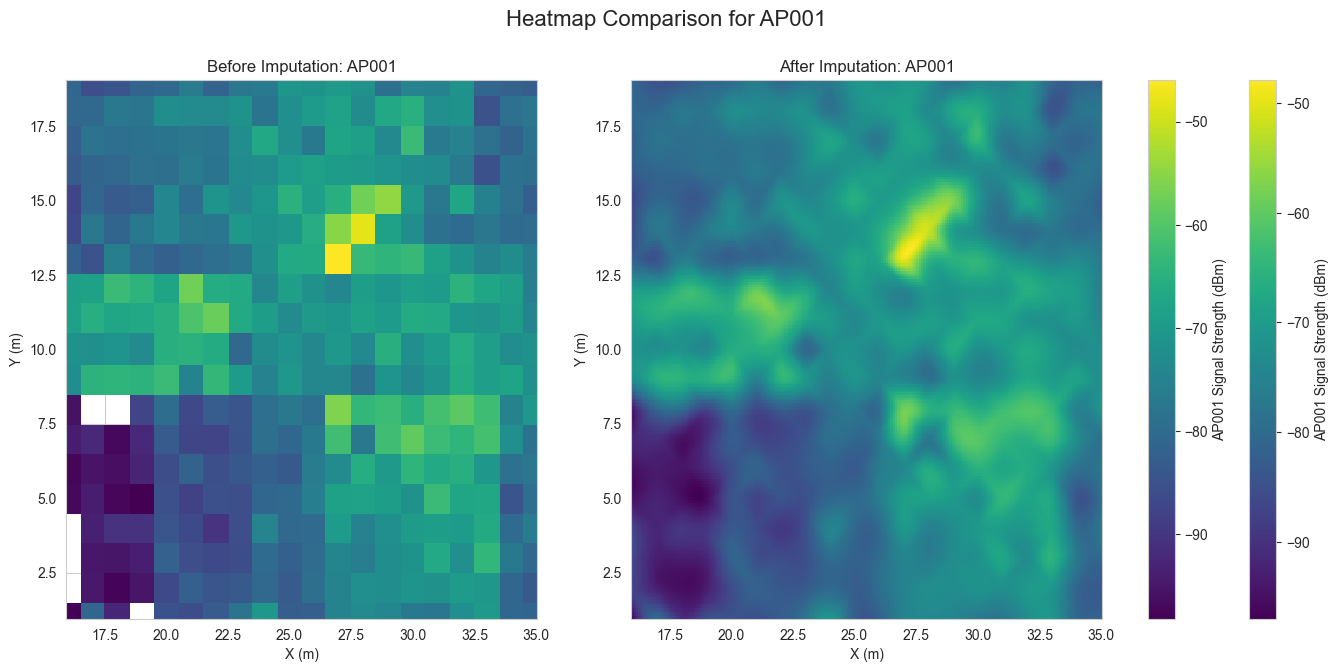

Interpolating data for AP002...


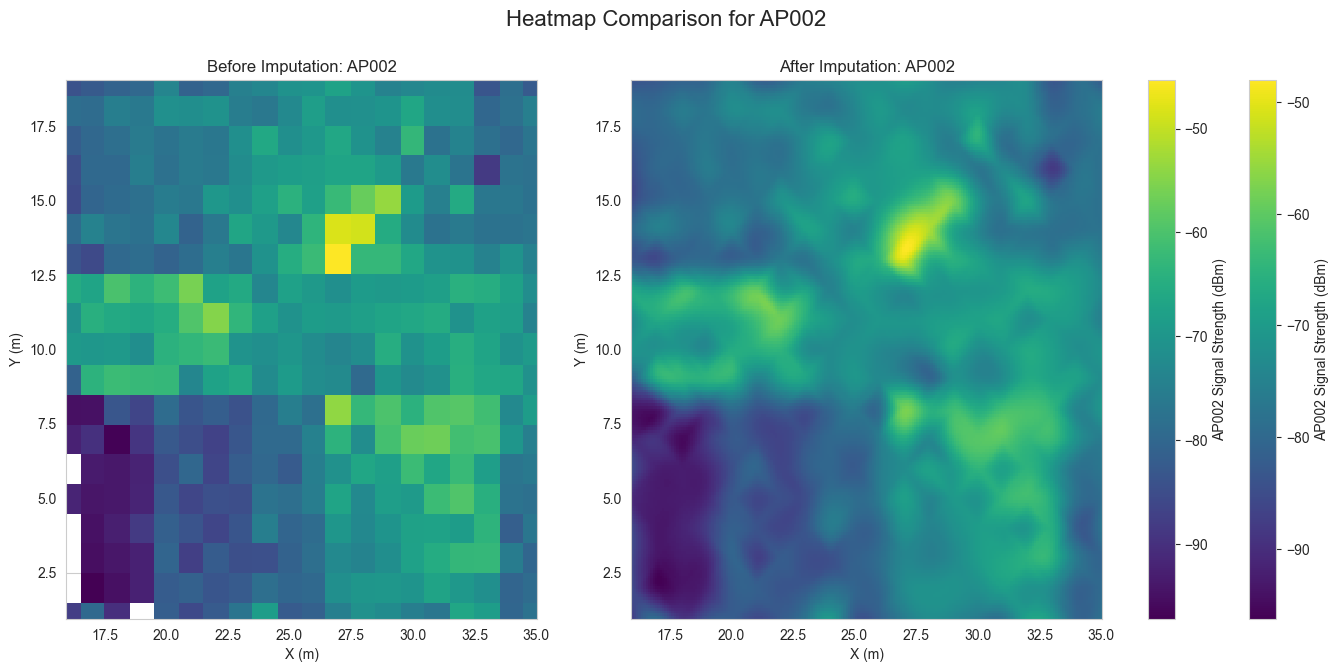

Interpolating data for AP003...


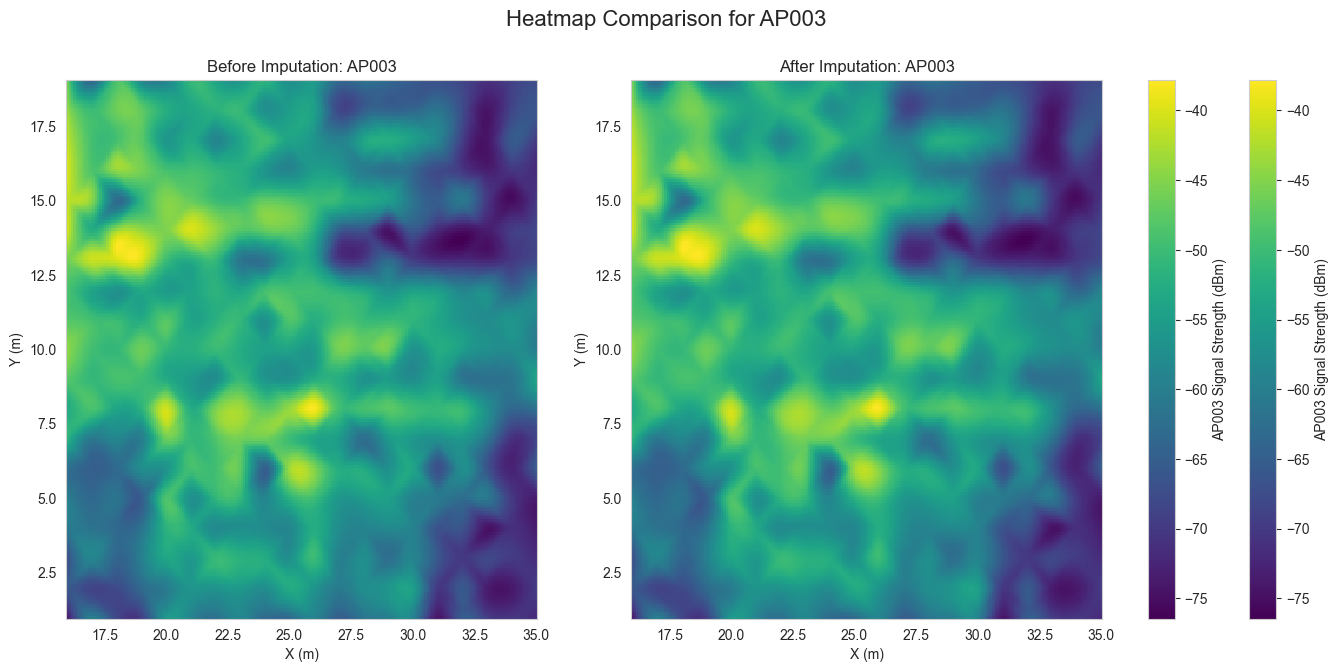

Interpolating data for AP004...


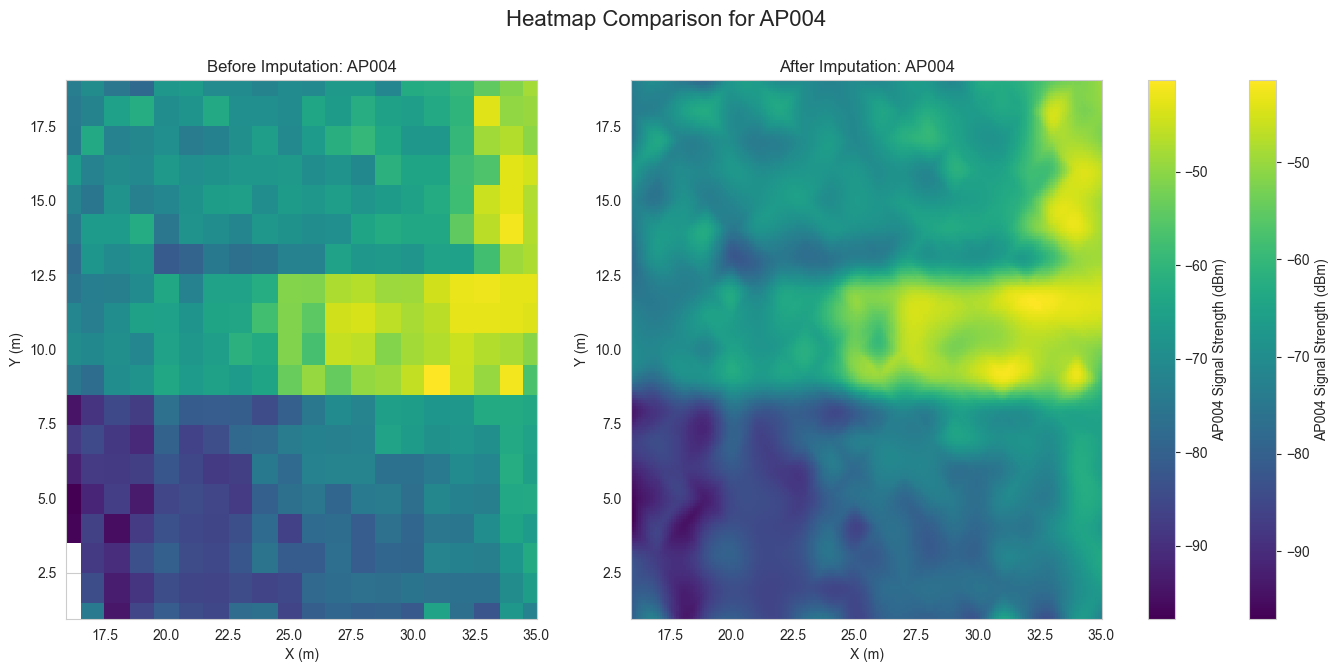

Interpolating data for AP005...


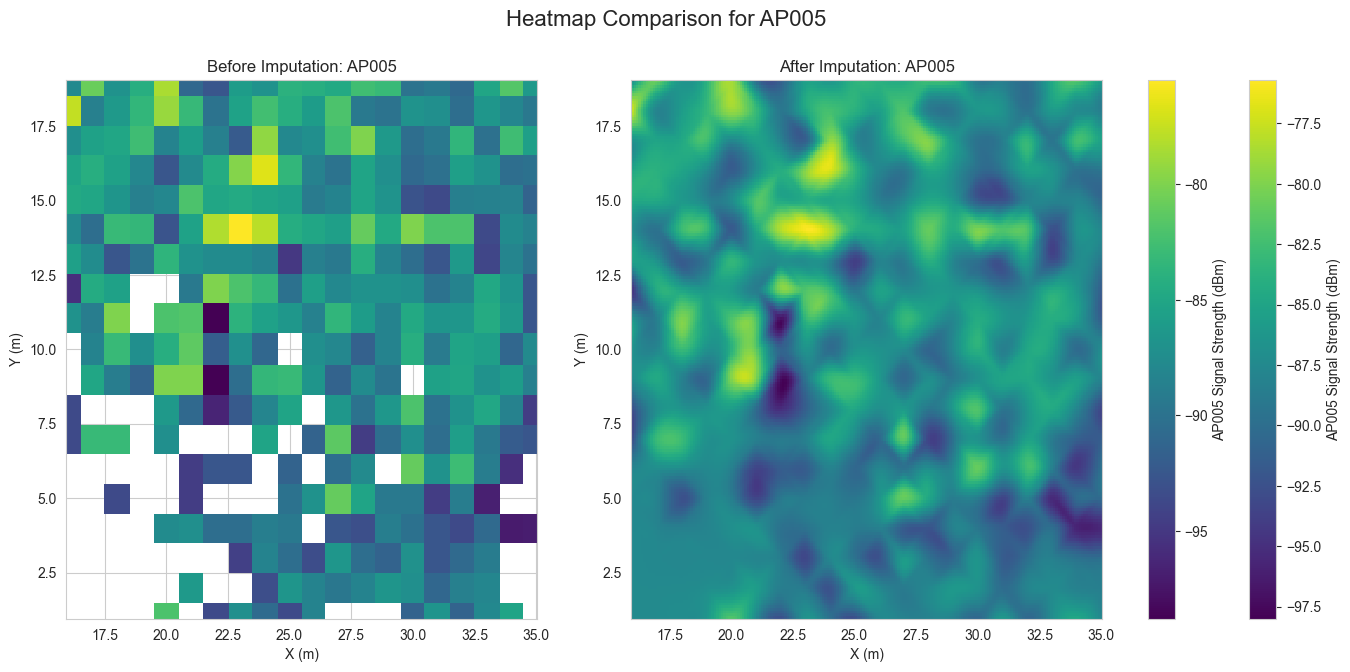

Interpolating data for AP006...


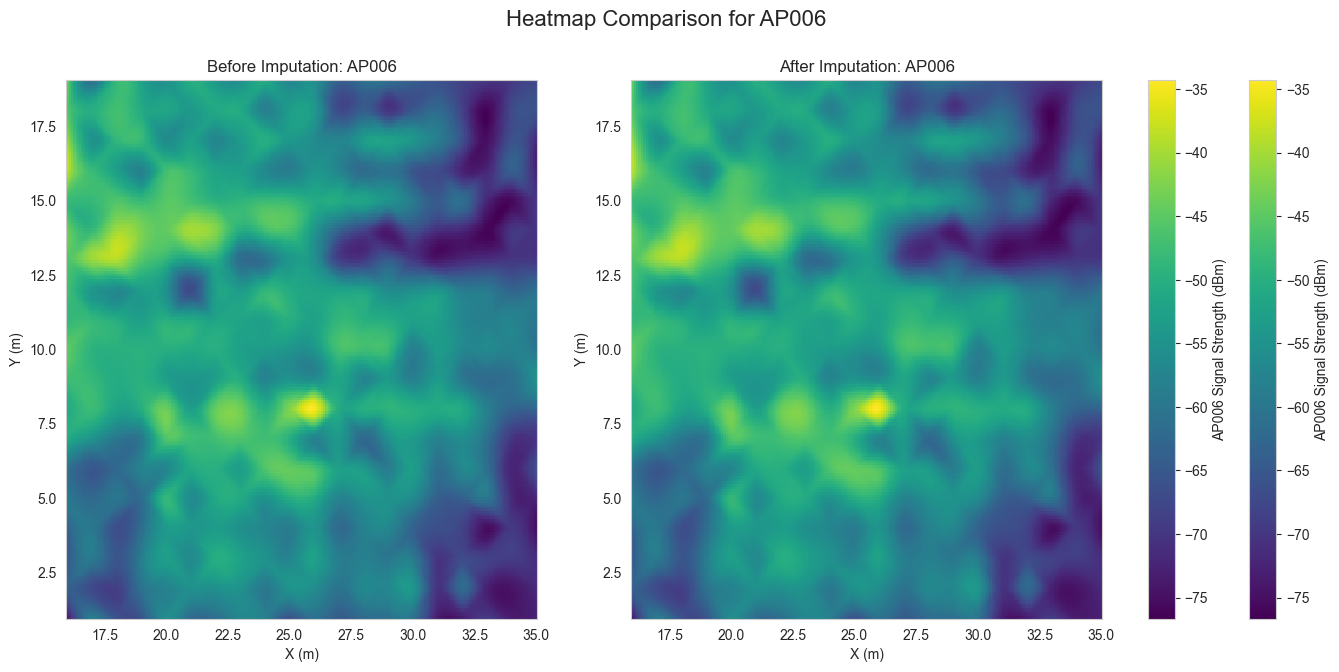

Interpolating data for AP007...


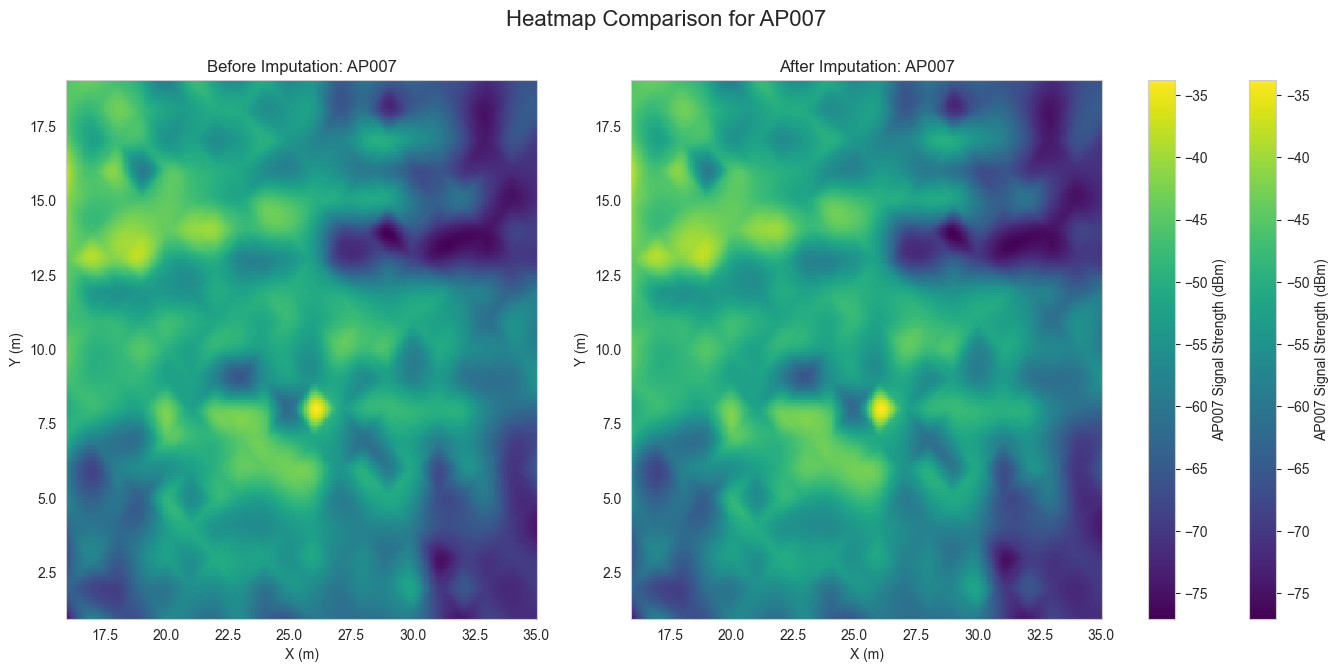

Interpolating data for AP008...


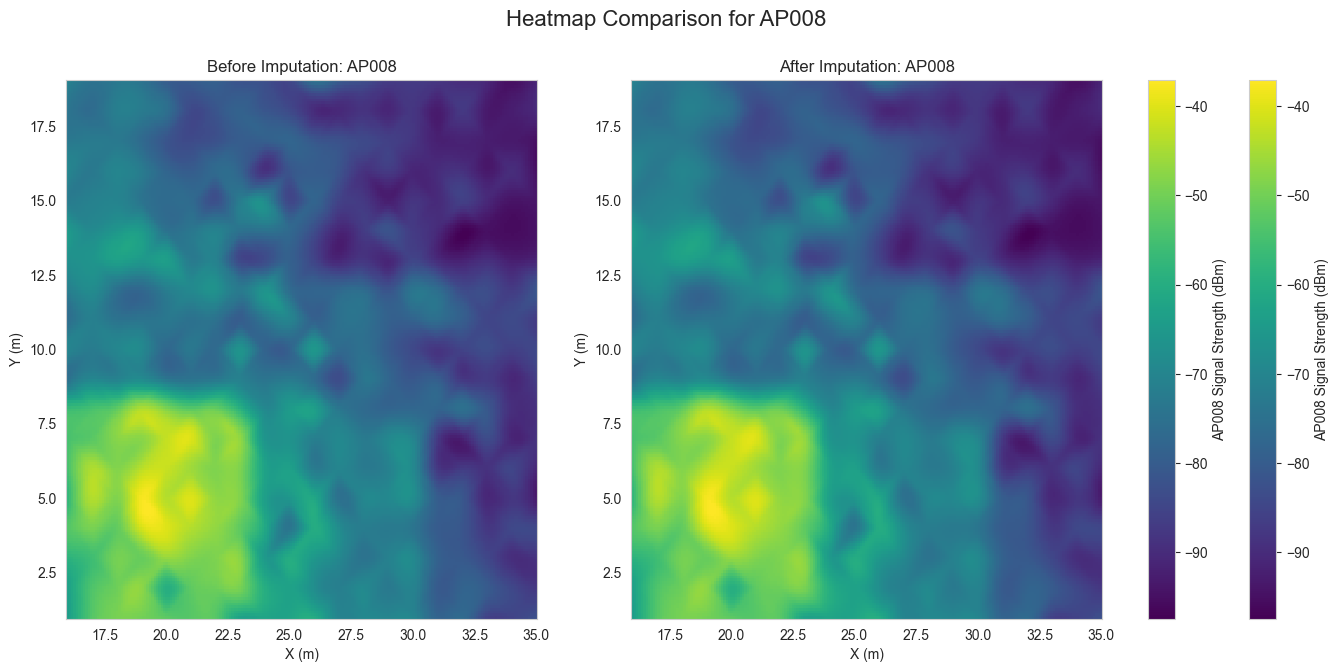

Interpolating data for AP010...


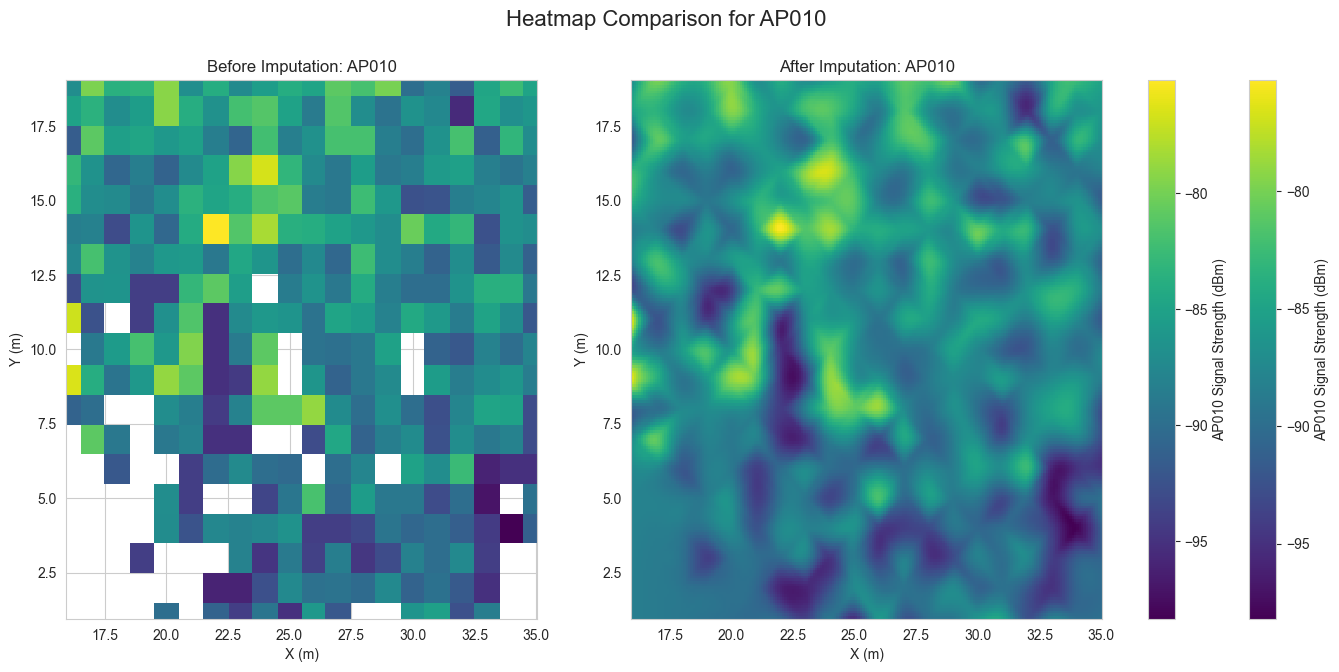

Interpolating data for AP011...


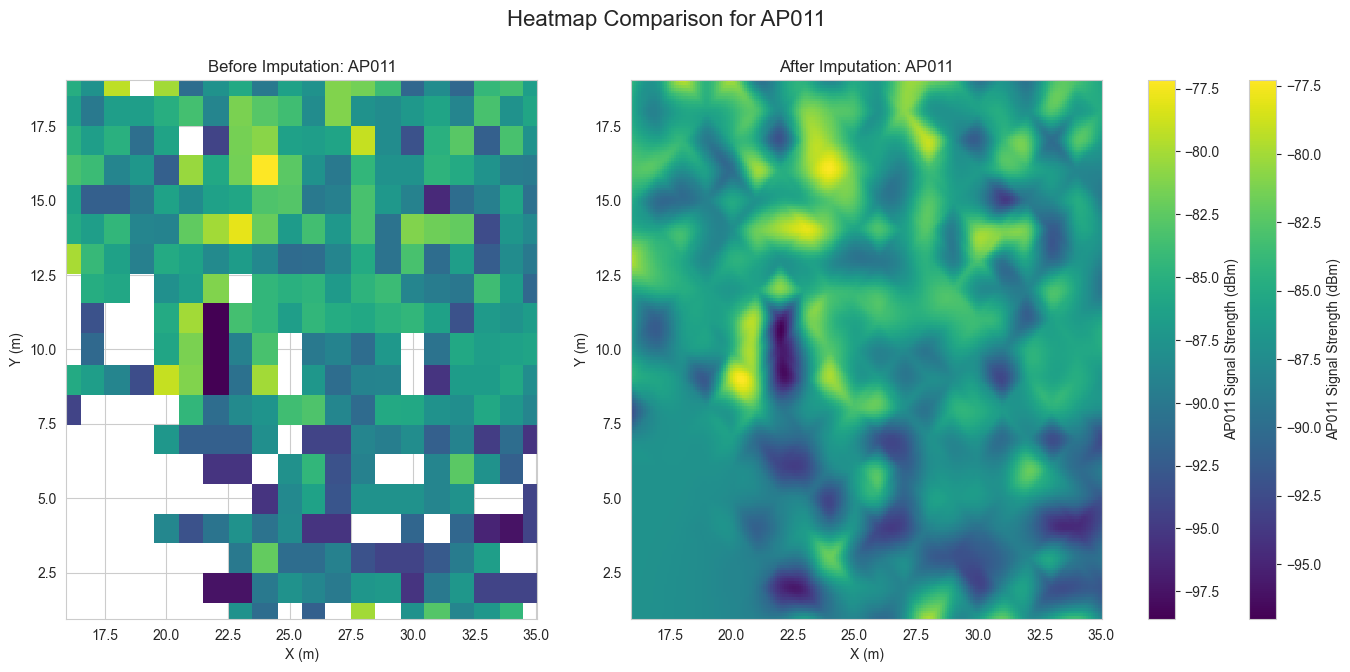

Interpolating data for AP014...


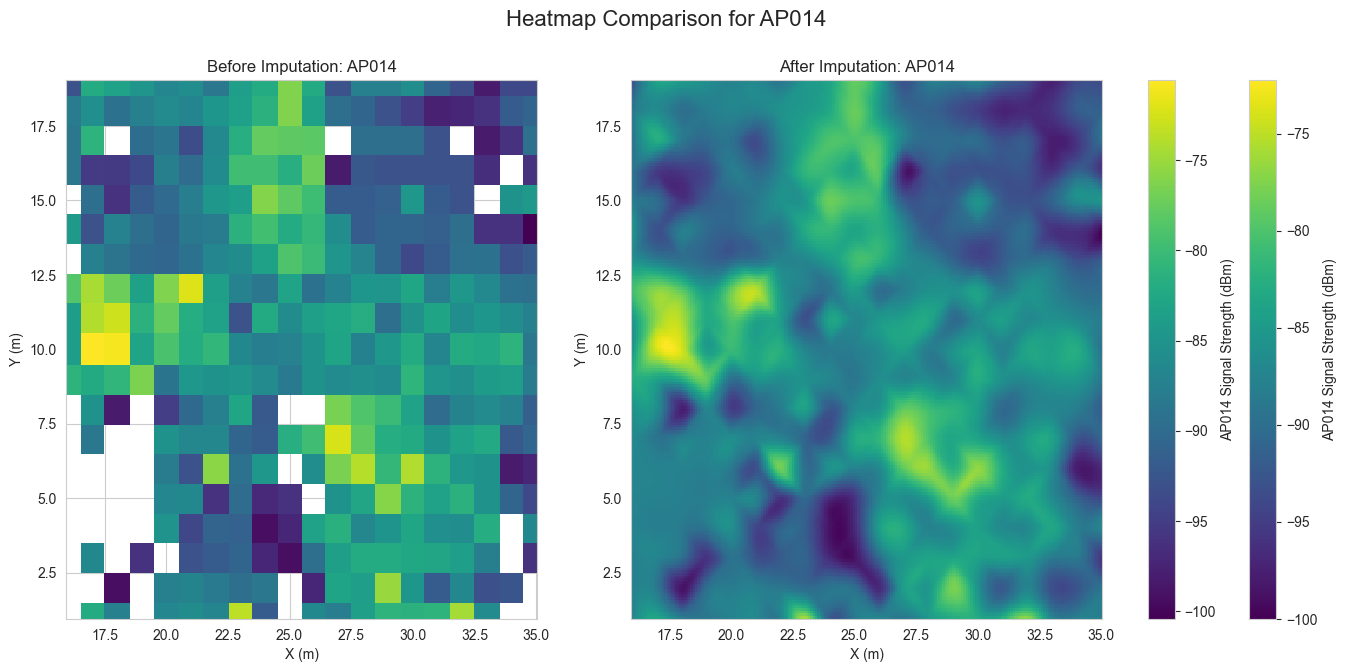

Interpolating data for AP017...


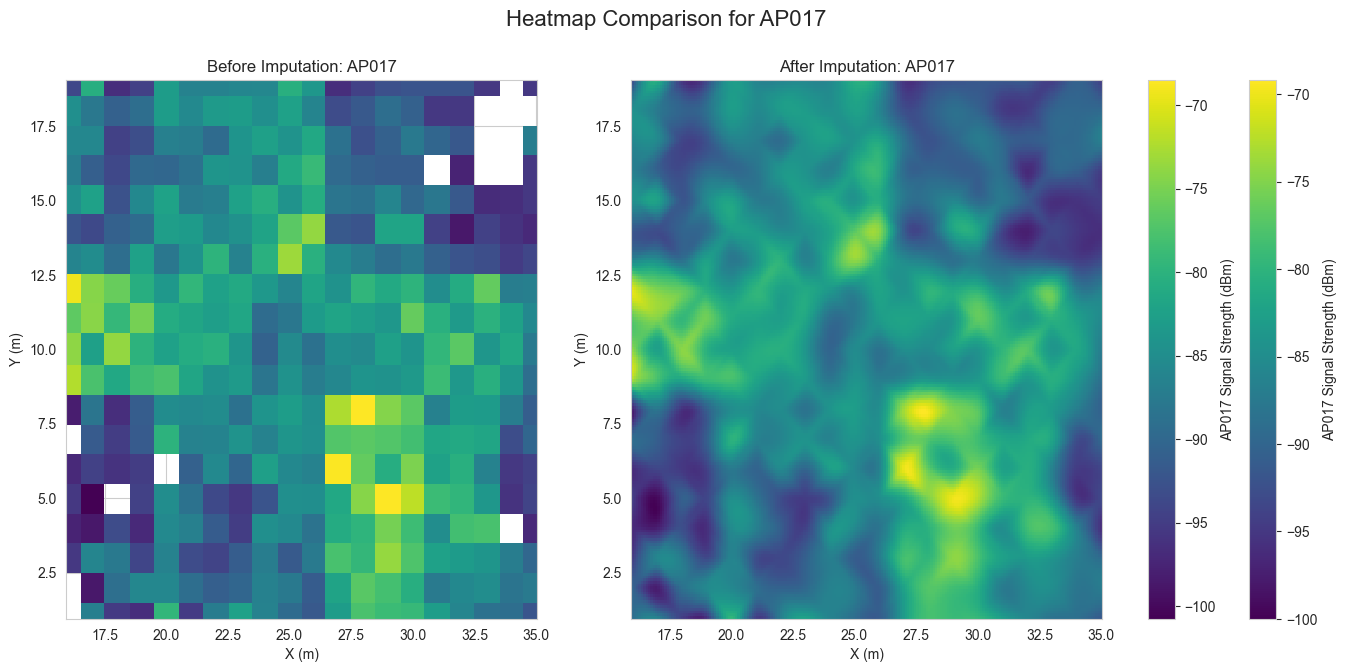

Interpolating data for AP019...


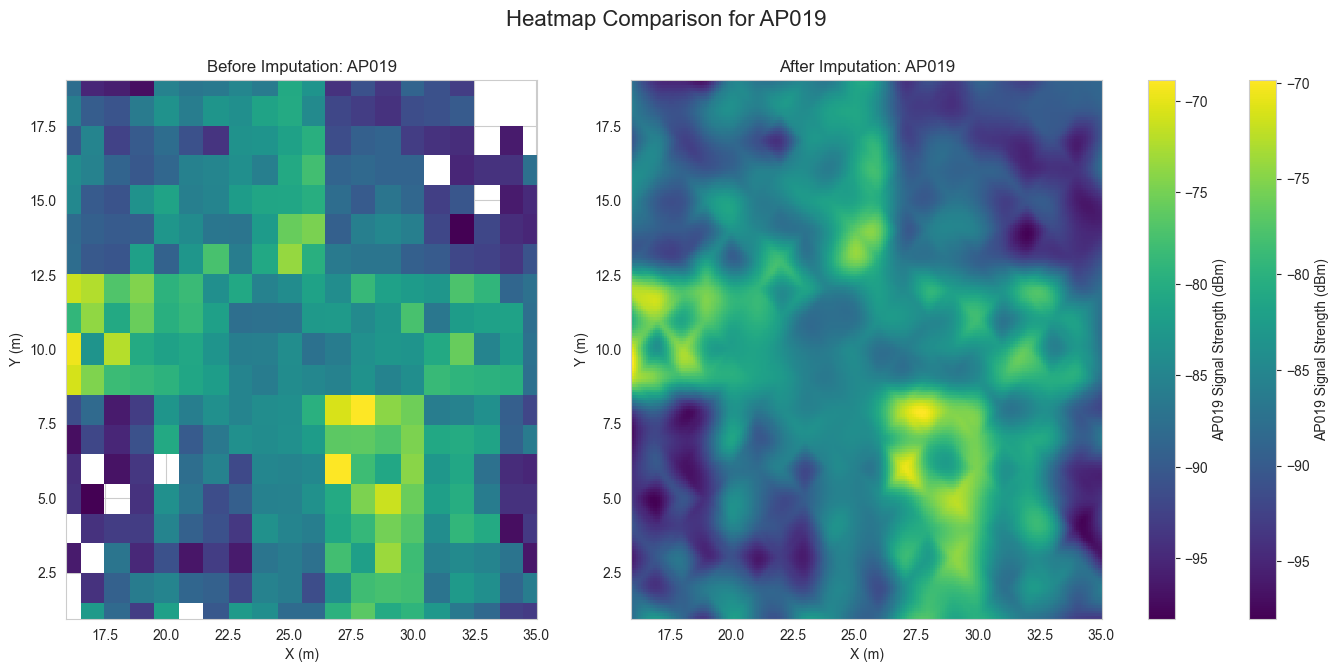

Interpolating data for AP021...


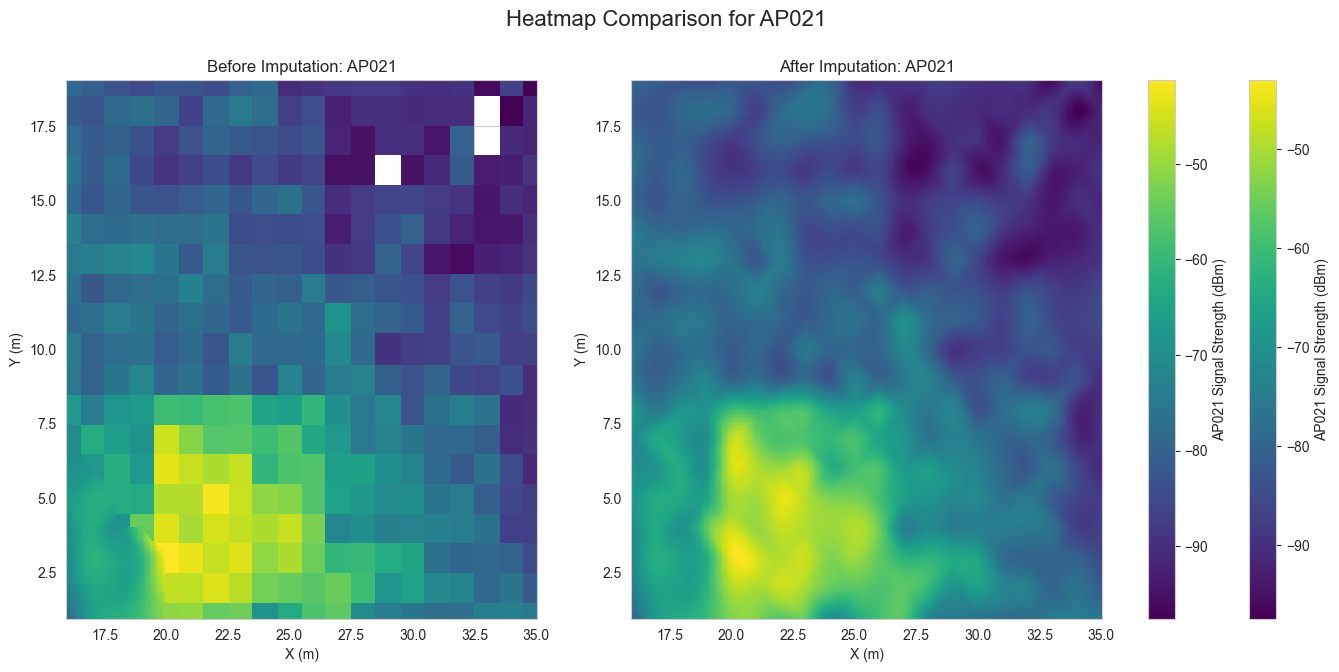

Interpolating data for AP023...


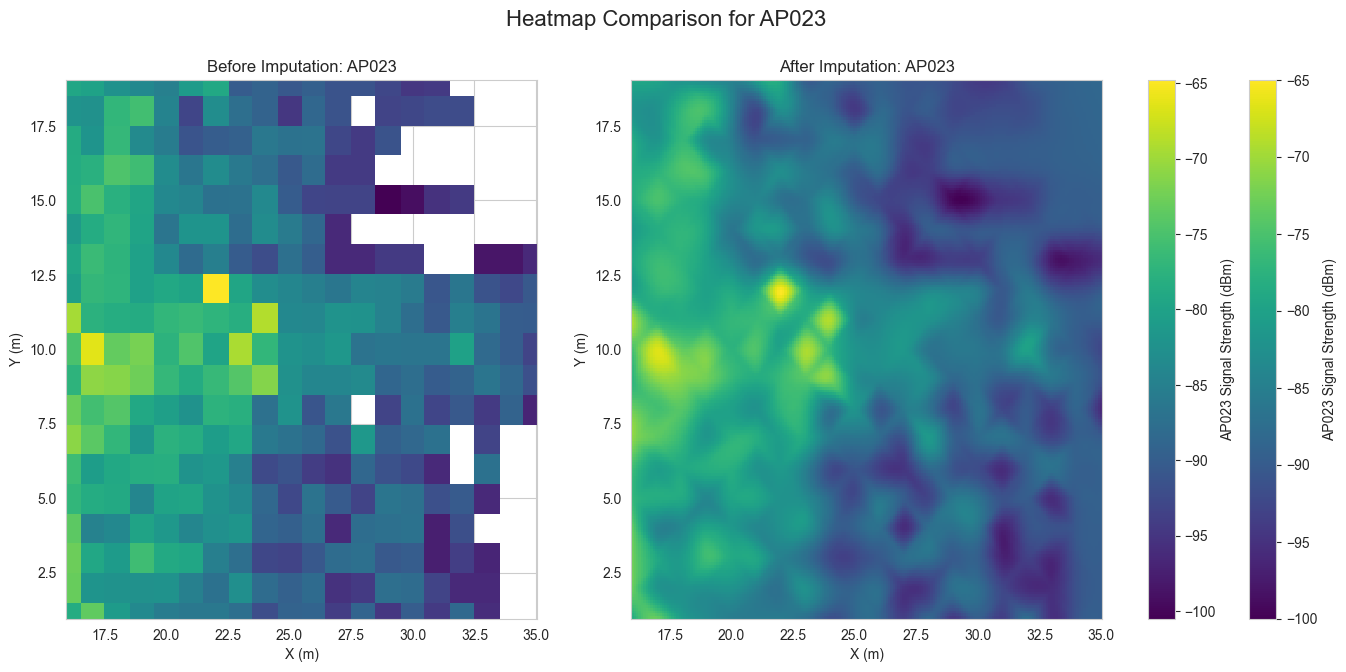

Interpolating data for AP024...


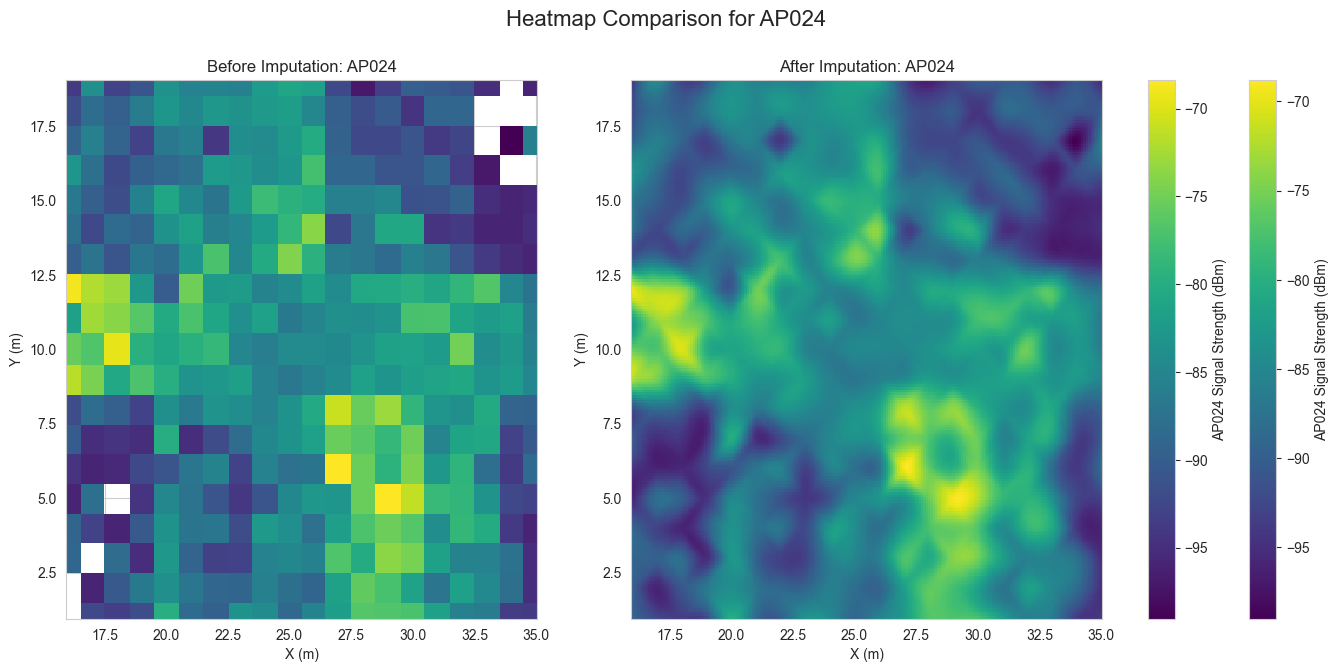

Interpolating data for AP029...


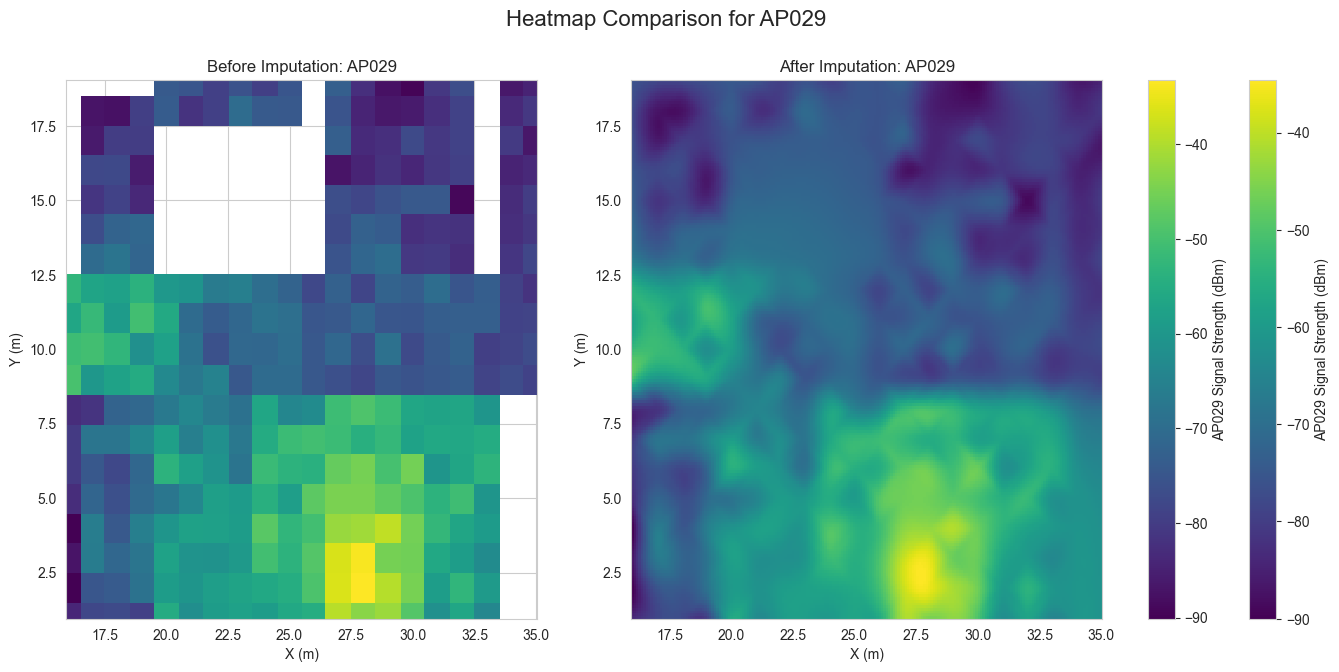

Interpolating data for AP030...


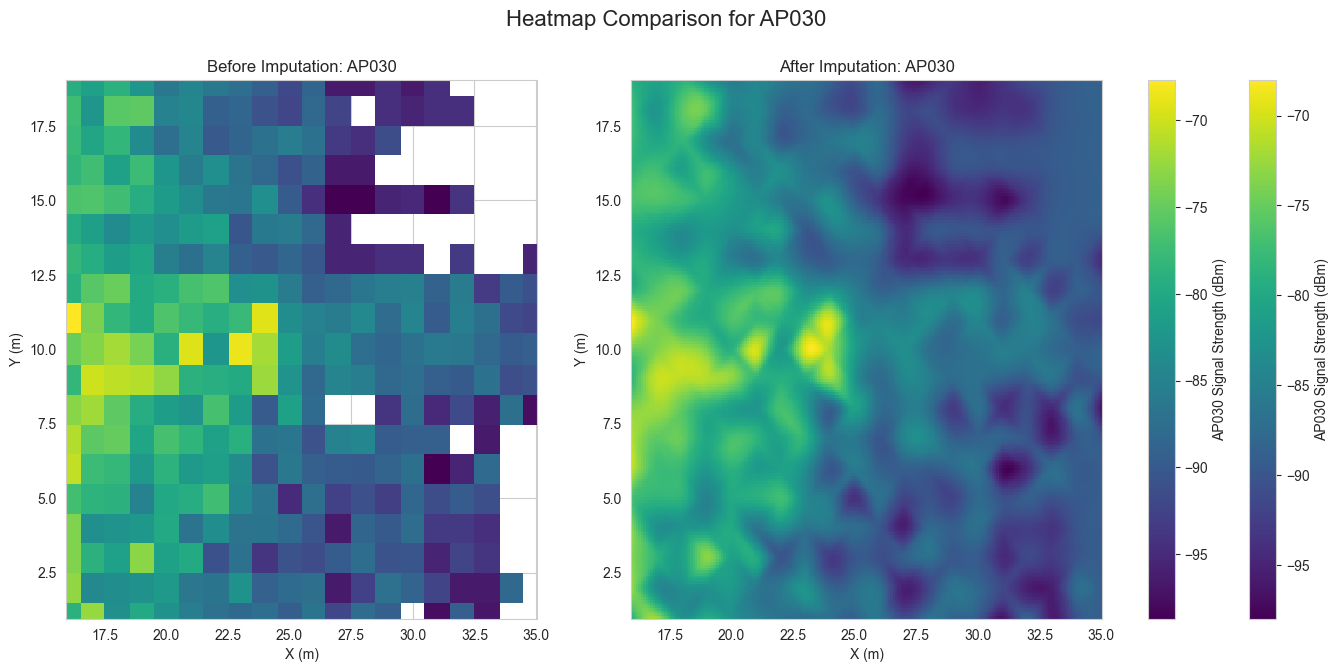

In [45]:
print("MEAN Imputed DataFrame:")
for ap_col in ap_cols:
    plot_side_by_side_heatmaps(ap_mean_by_xy, ap_mean_by_xy_imputed, ap_col)

In [73]:
# Saving the dataset to a file
ap_mean_by_xy_imputed.to_csv("./ap_mean_by_xy_imputed_IDW.csv", index=False)

In [48]:
ap_mean_by_xy.to_csv("./ap_mean_by_xy.csv", index=False)

## Imputation for MEDIAN dataset

### IDW Imputation

In [46]:
ap_median_by_xy_imputed = ap_median_by_xy.copy(deep=True)

for ap_col in ap_cols:
    XX, YY, ZZ, new_values, mask = impute_and_plot_heatmap(
        df=ap_median_by_xy,
        x_col='X',
        y_col='Y',
        ap_col=ap_col,
        num_samples=200,
        power=2
    )

    # We use the 'mask' to ensure we only fill the exact rows that were calculated
    if len(new_values) > 0:
        ap_median_by_xy_imputed.loc[mask, ap_col] = new_values
        print(f"Updated DataFrame: Filled {len(new_values)} missing values for {ap_col}.")
    else:
        print(f"No missing values required filling for {ap_col}.")

print("\nImputation Complete.")
print(f"Original DataFrame **ap_median_by_xy** has {ap_median_by_xy.isna().sum().sum()} total NaNs.")
print(f"Imputed DataFrame **ap_median_by_xy_imputed** has {ap_median_by_xy_imputed.isna().sum().sum()} total NaNs (should be 0 for the imputed columns).")


Updated DataFrame: Filled 6 missing values for AP001.
Updated DataFrame: Filled 5 missing values for AP002.
No missing values required filling for AP003.
Updated DataFrame: Filled 3 missing values for AP004.
Updated DataFrame: Filled 66 missing values for AP005.
No missing values required filling for AP006.
No missing values required filling for AP007.
No missing values required filling for AP008.
Updated DataFrame: Filled 55 missing values for AP010.
Updated DataFrame: Filled 77 missing values for AP011.
Updated DataFrame: Filled 43 missing values for AP014.
Updated DataFrame: Filled 15 missing values for AP017.
Updated DataFrame: Filled 18 missing values for AP019.
Updated DataFrame: Filled 3 missing values for AP021.
Updated DataFrame: Filled 52 missing values for AP023.
Updated DataFrame: Filled 11 missing values for AP024.
Updated DataFrame: Filled 70 missing values for AP029.
Updated DataFrame: Filled 52 missing values for AP030.

Imputation Complete.
Original DataFrame **ap_medi

MEDIAN Imputed DataFrame:
Interpolating data for AP001...


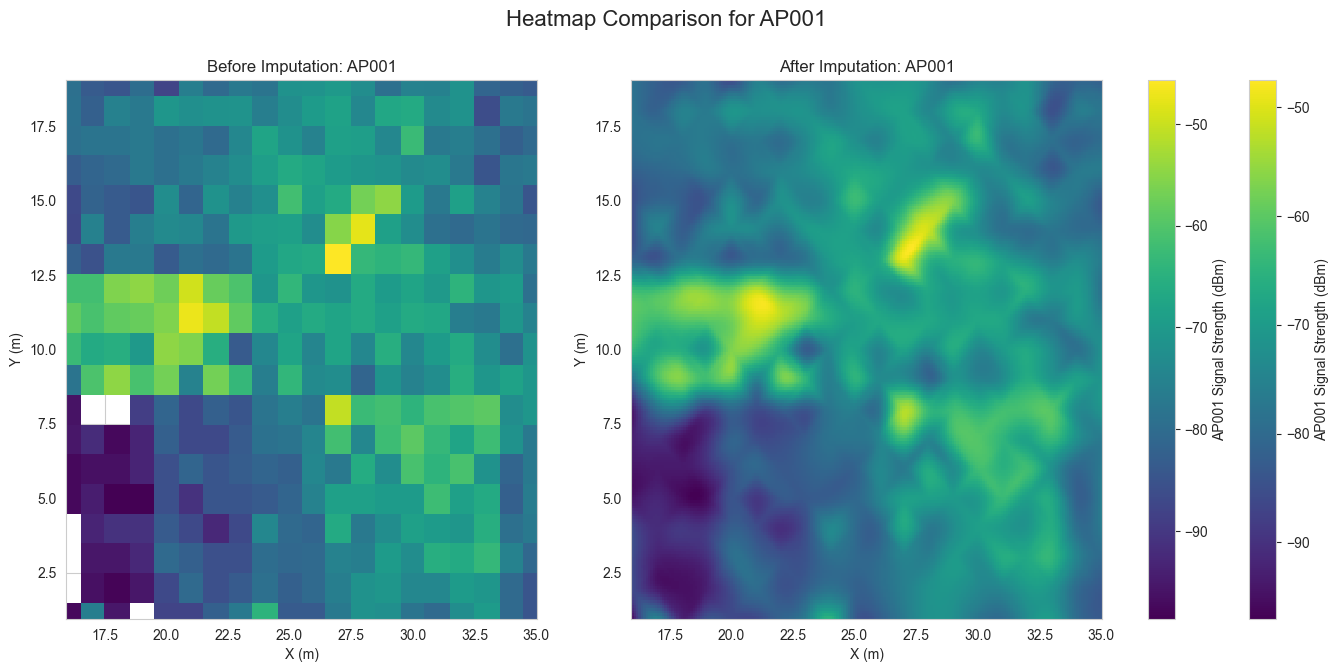

Interpolating data for AP002...


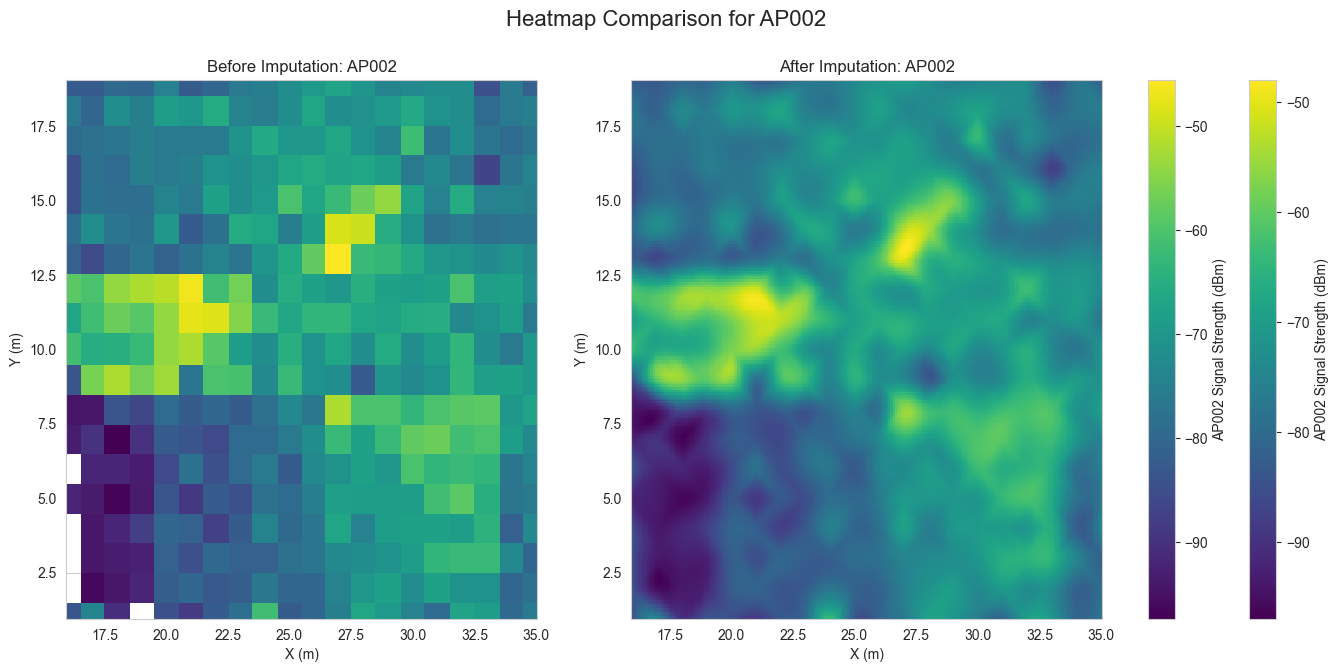

Interpolating data for AP003...


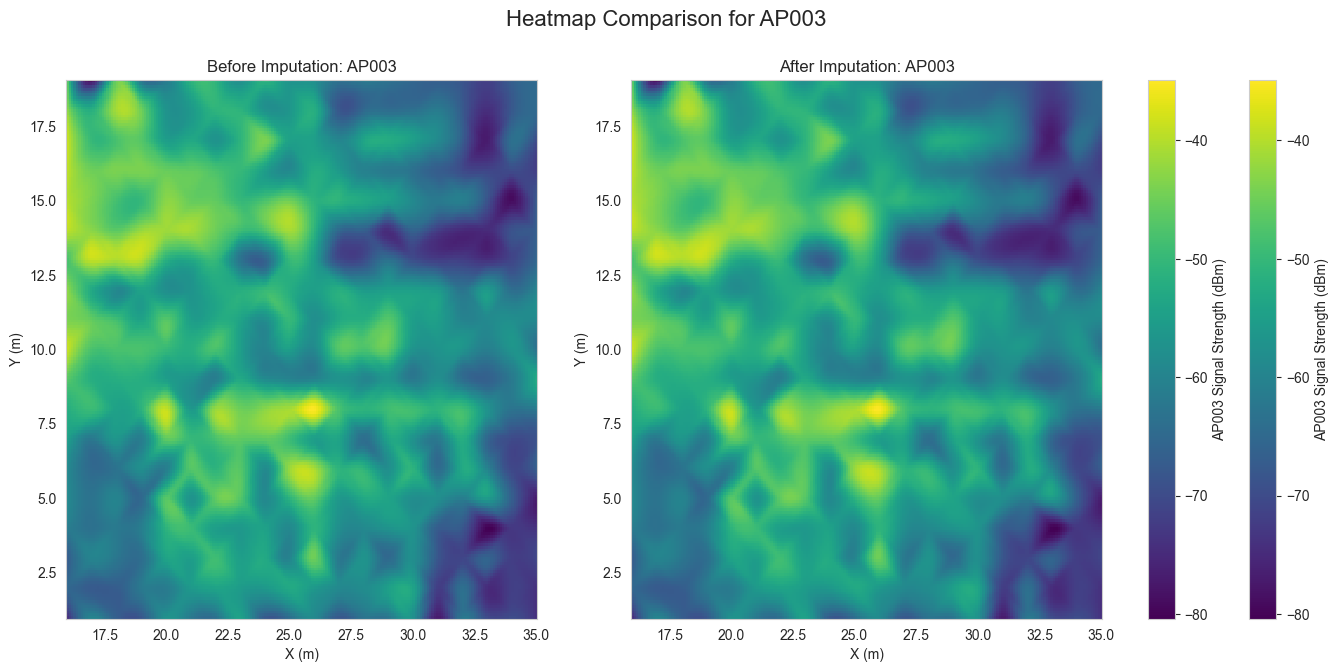

Interpolating data for AP004...


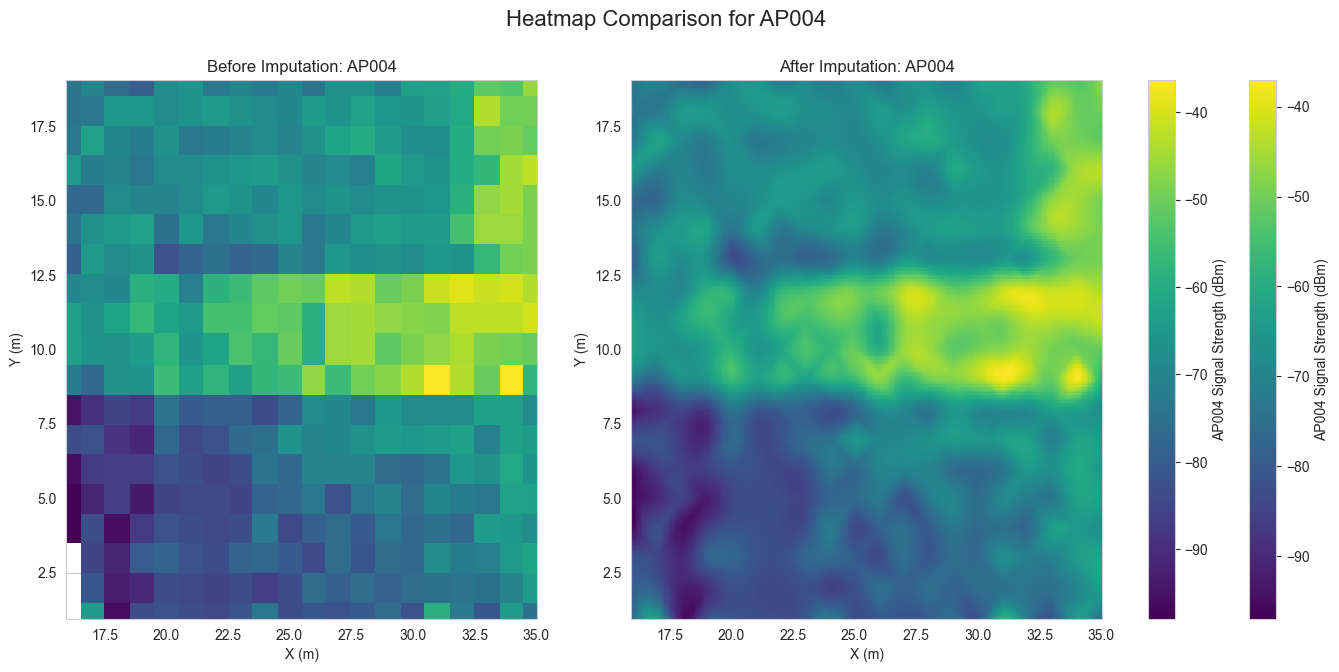

Interpolating data for AP005...


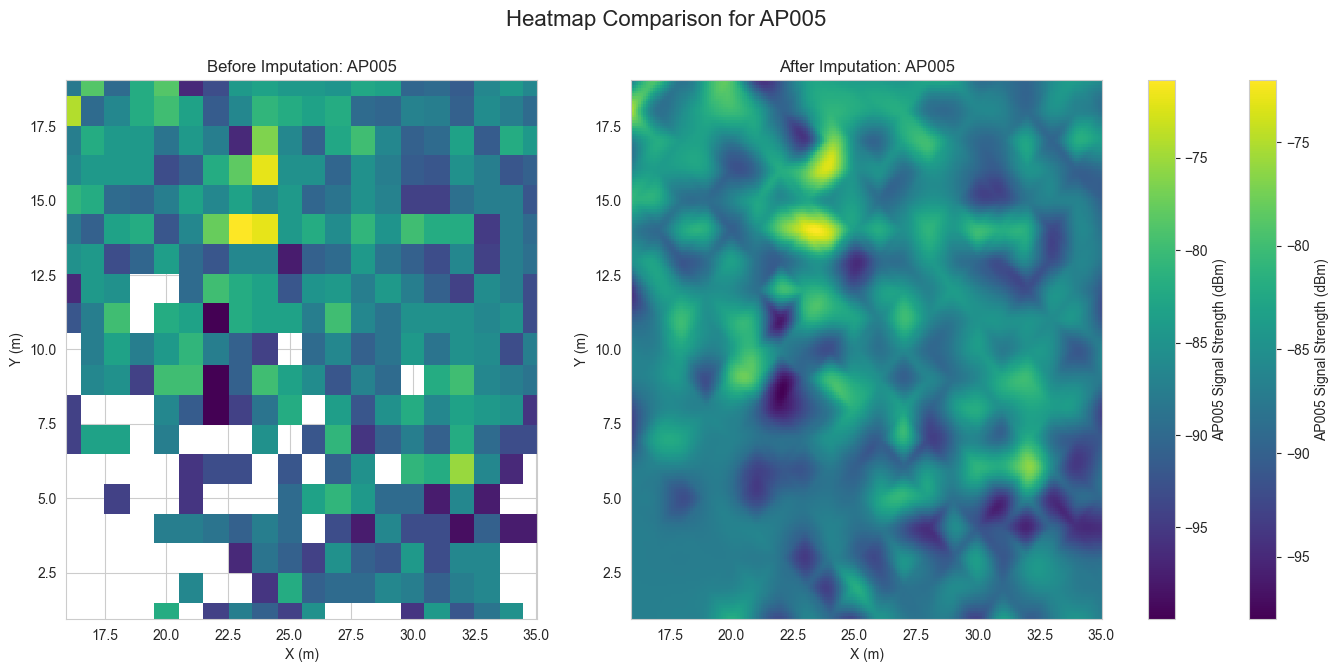

Interpolating data for AP006...


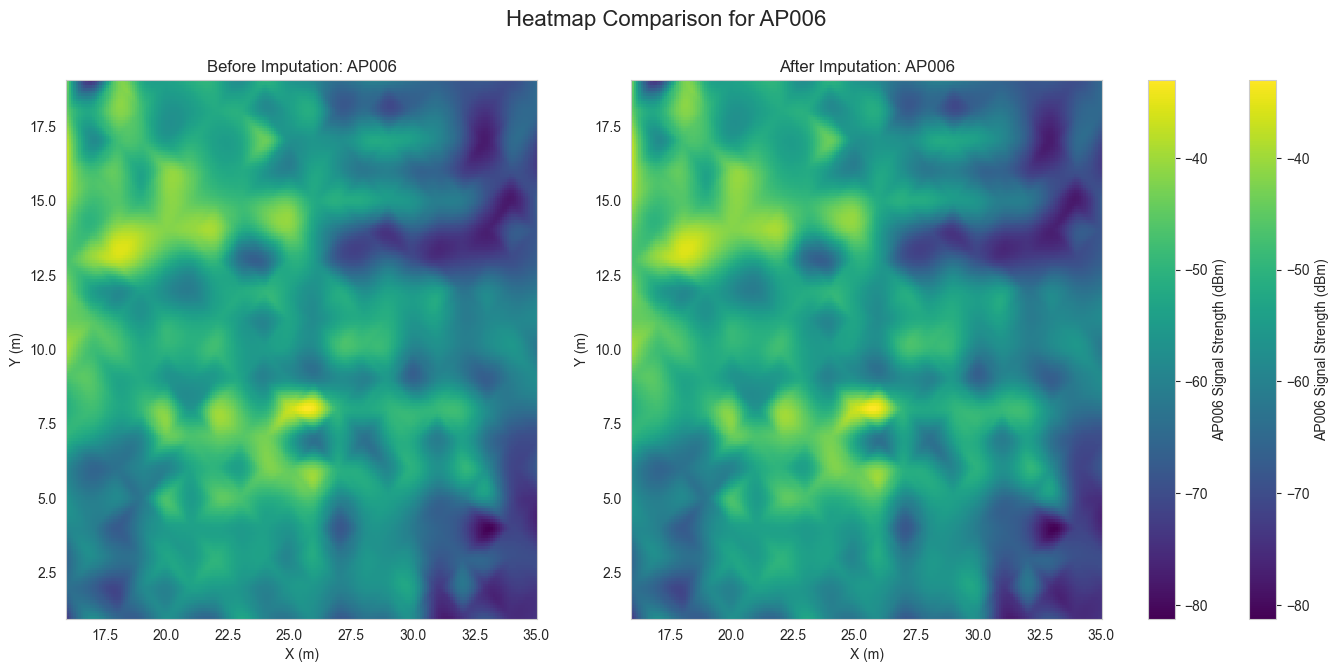

Interpolating data for AP007...


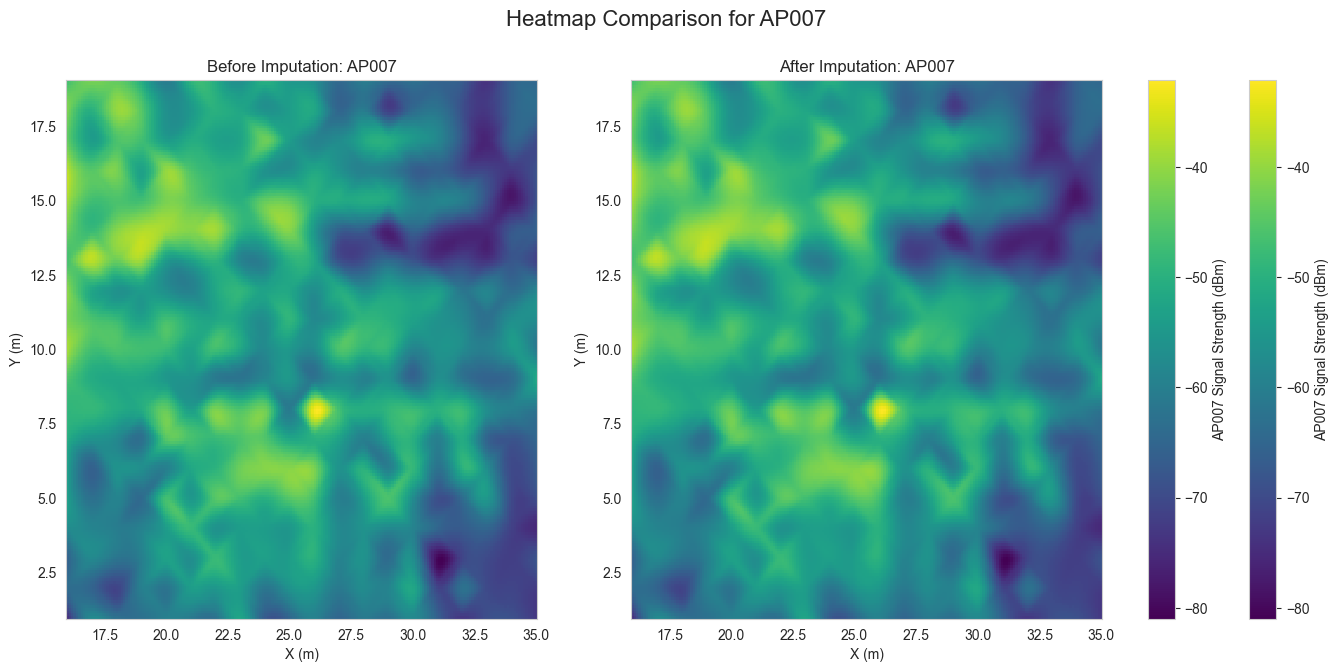

Interpolating data for AP008...


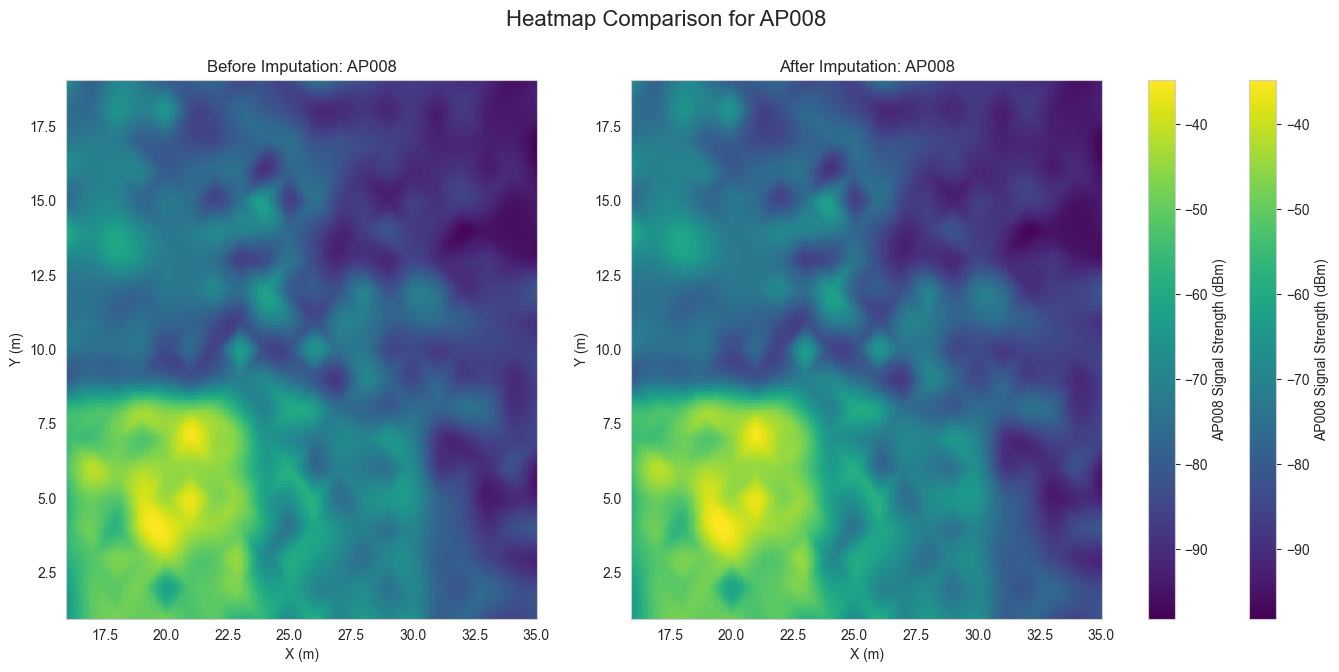

Interpolating data for AP010...


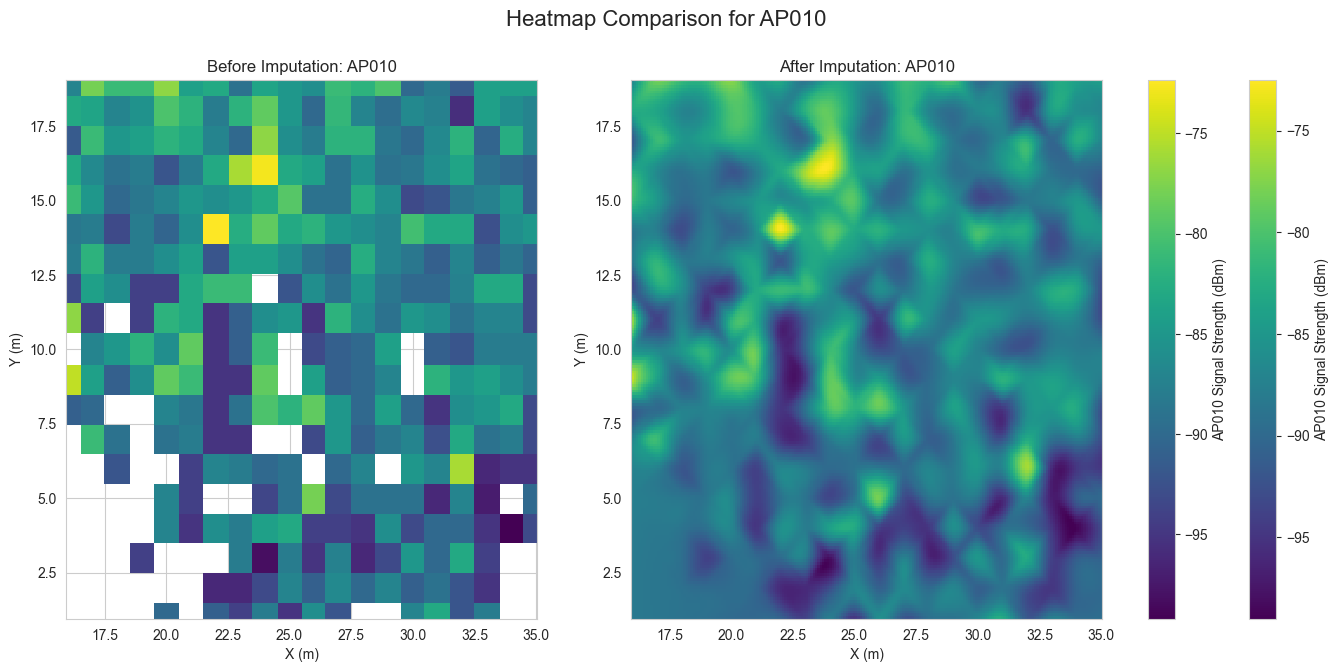

Interpolating data for AP011...


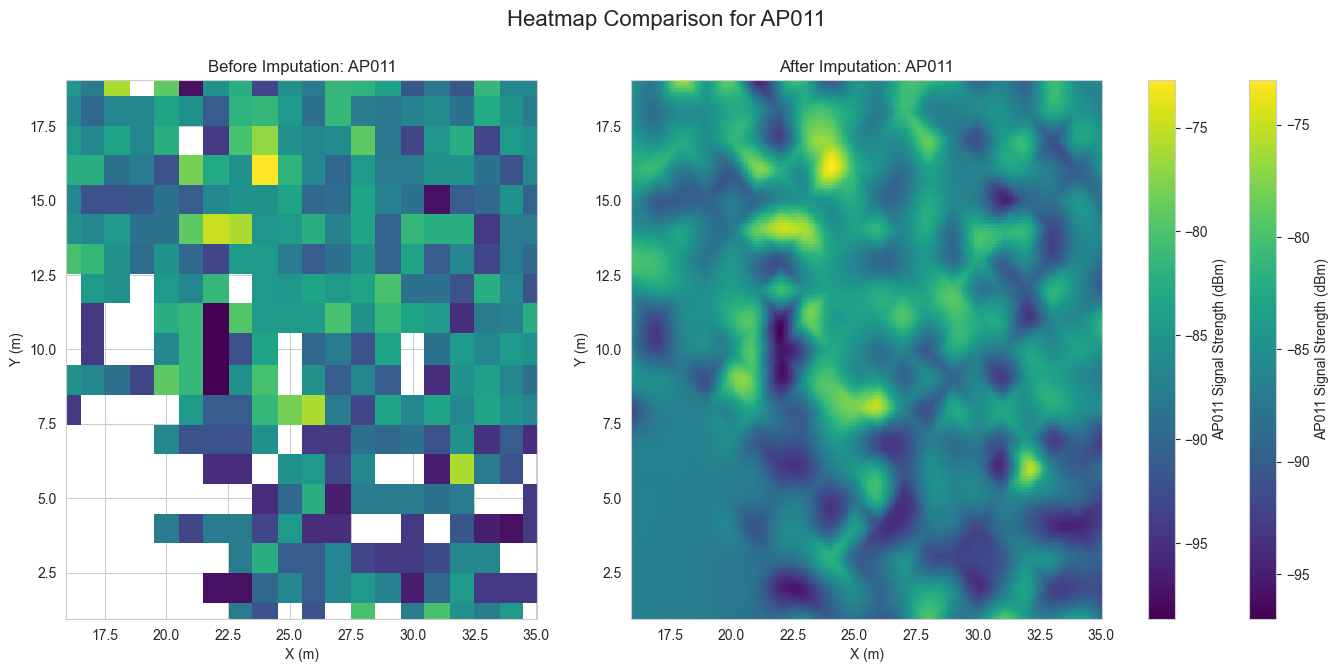

Interpolating data for AP014...


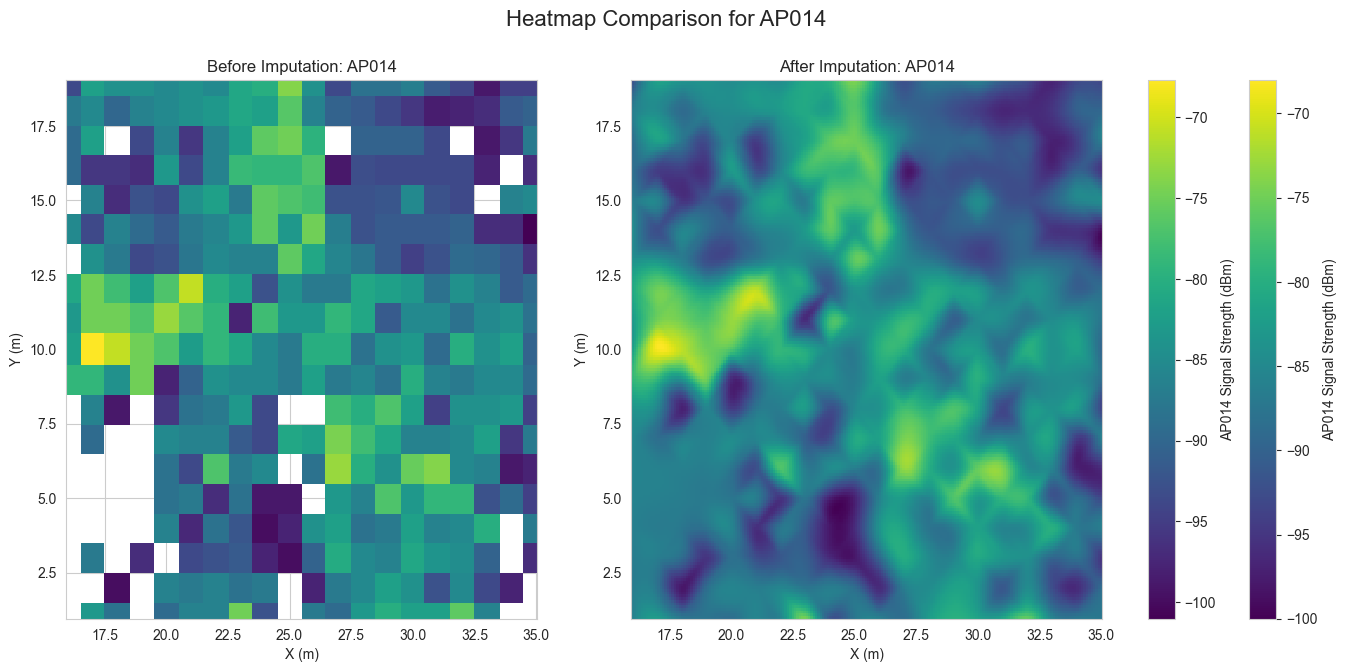

Interpolating data for AP017...


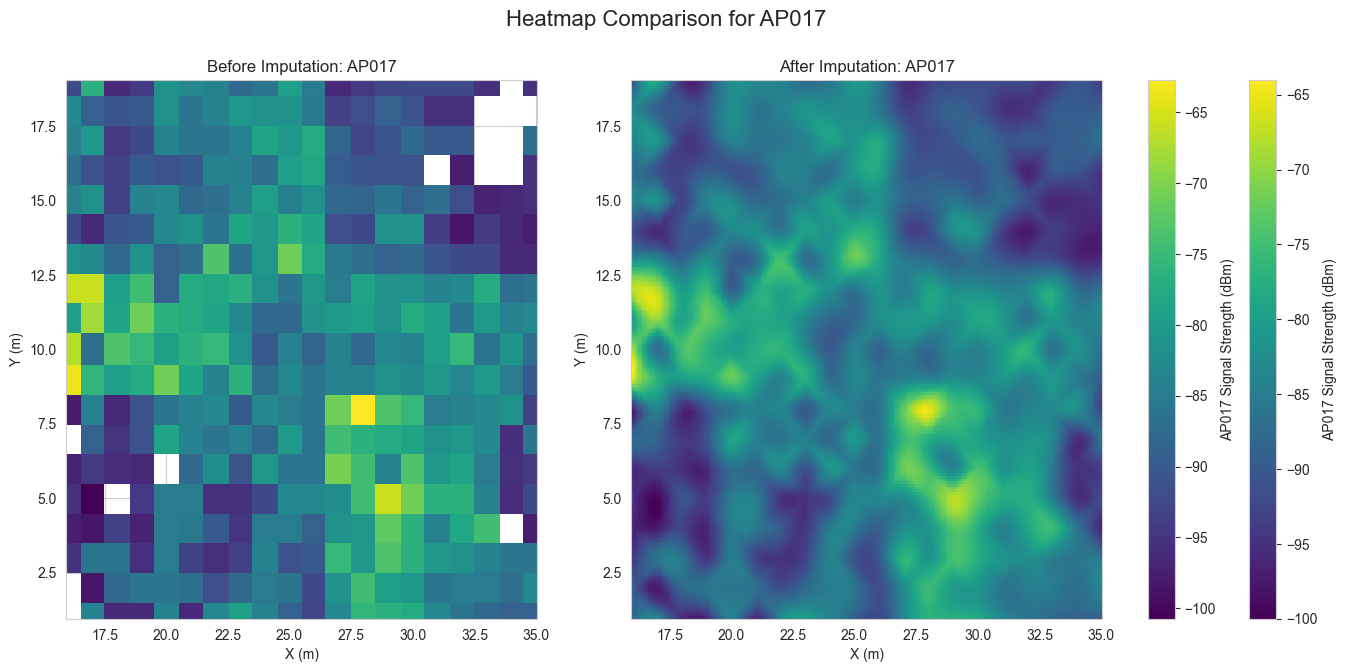

Interpolating data for AP019...


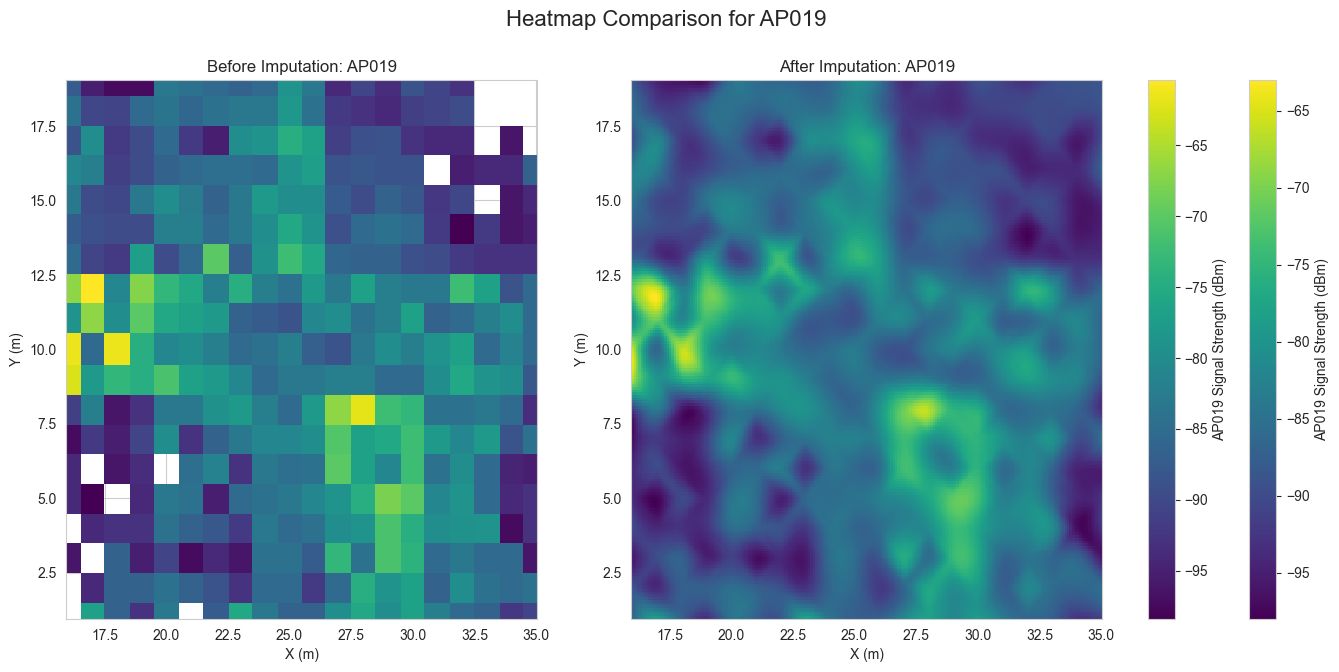

Interpolating data for AP021...


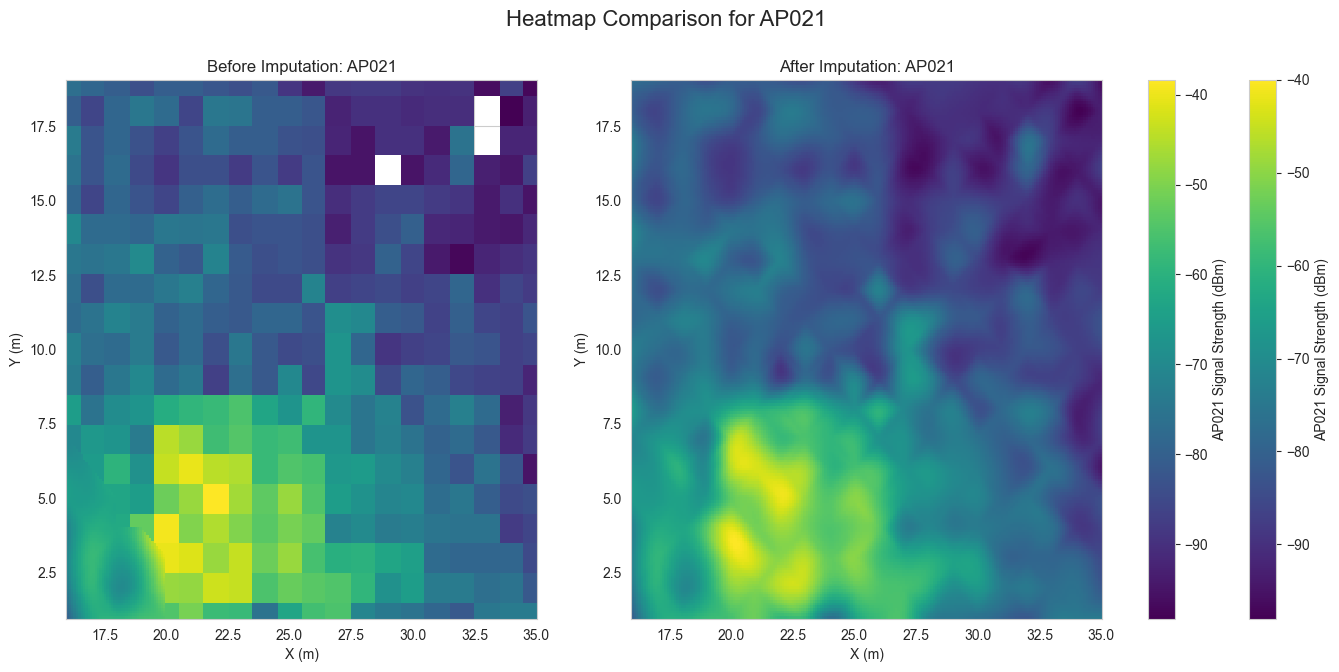

Interpolating data for AP023...


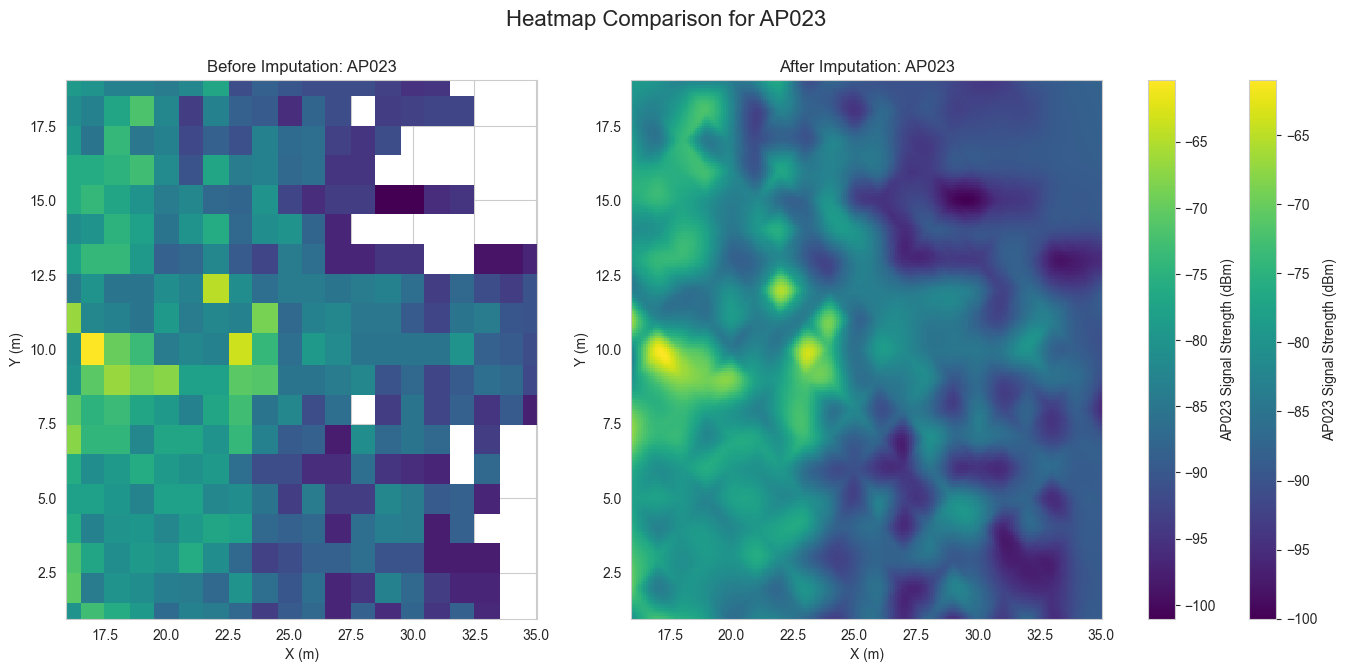

Interpolating data for AP024...


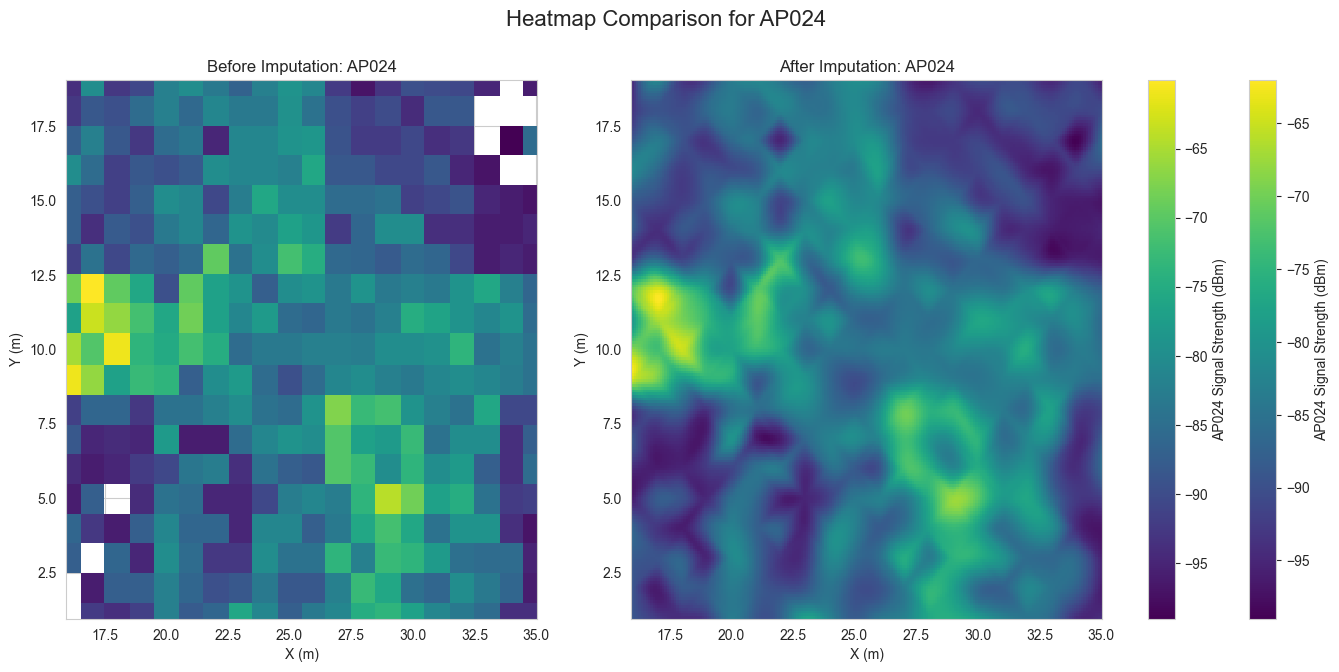

Interpolating data for AP029...


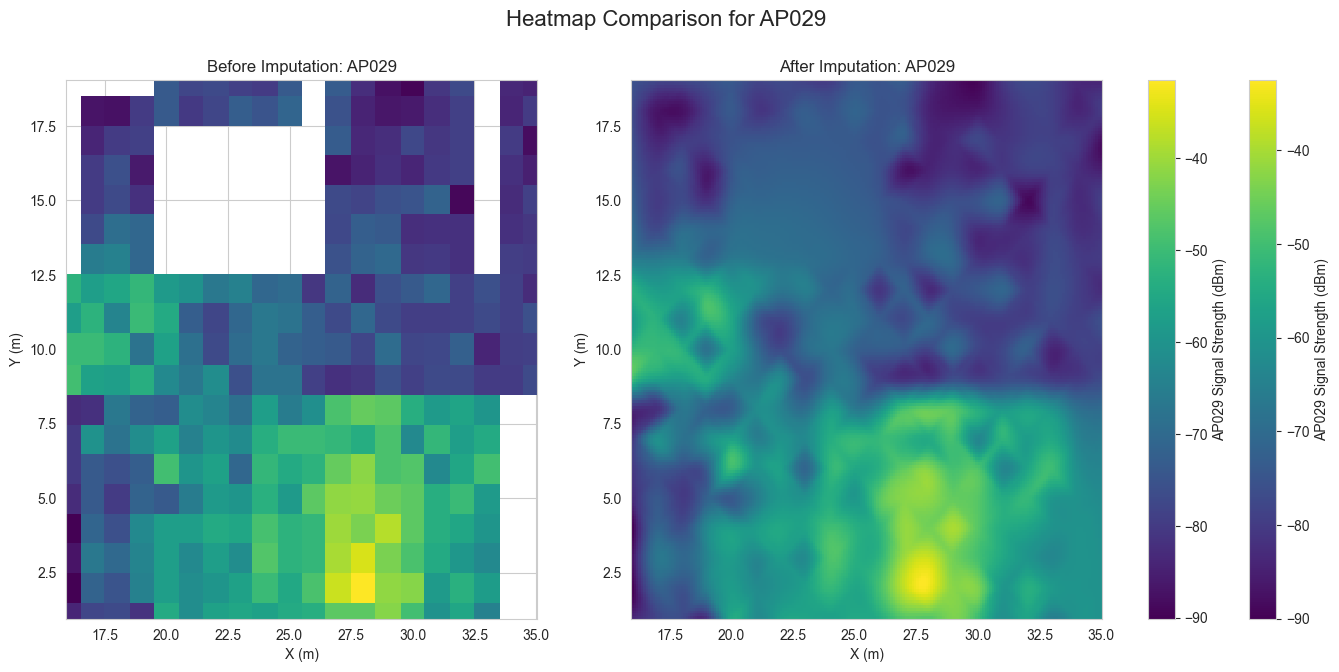

Interpolating data for AP030...


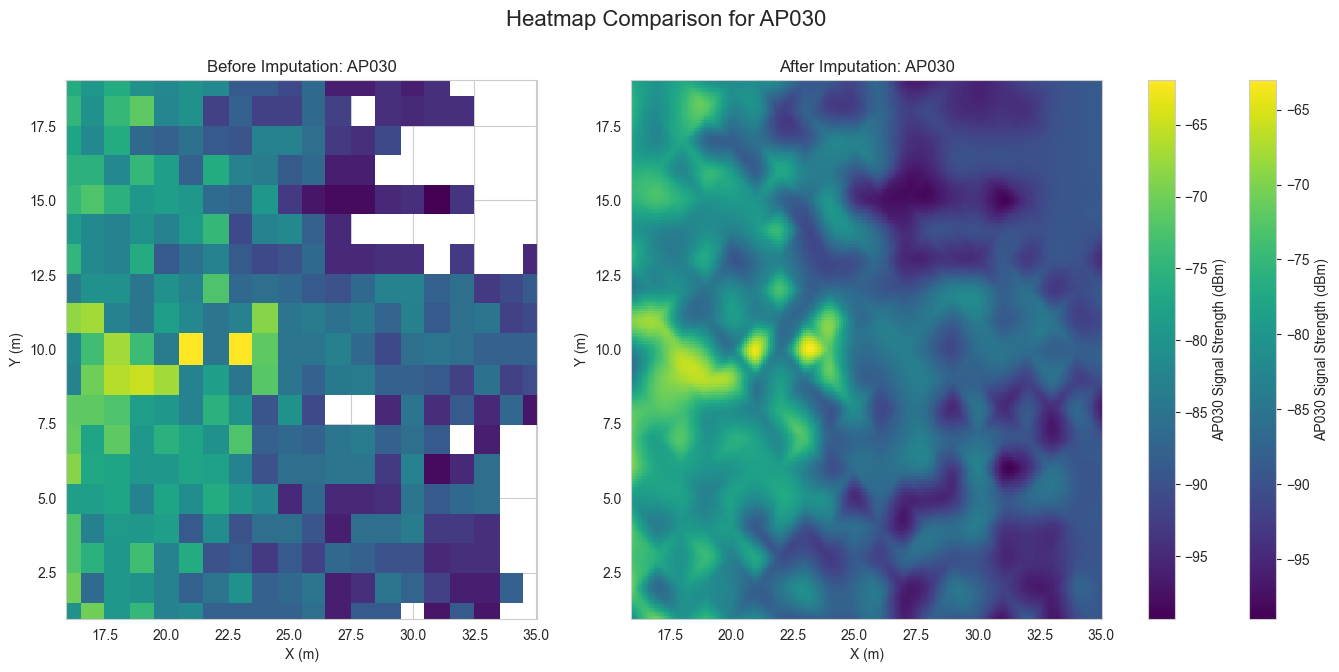

In [47]:
print("MEDIAN Imputed DataFrame:")
for ap_col in ap_cols:
    plot_side_by_side_heatmaps(ap_median_by_xy, ap_median_by_xy_imputed, ap_col)

In [76]:
# Saving the dataset to a file
ap_median_by_xy_imputed.to_csv("./ap_median_by_xy_imputed_IDW.csv", index=False)

In [49]:
ap_median_by_xy.to_csv("./ap_median_by_xy.csv", index=False)